# 03 bis — Préparation des données pour le surrogate

**Objectif** : nettoyer, analyser et préparer le dataset `eval_database.json` avant
l'entraînement du modèle surrogate (notebook 04).

### Pipeline
1. Chargement & inspection brute
2. Détection des outliers VLM (divergences numériques)
3. Analyse de la qualité par cible (7 primitives)
4. Filtrage et constitution du dataset propre
5. Analyse des corrélations features ↔ targets
6. Vérification de la couverture du design space
7. Export du dataset nettoyé prêt pour l'entraînement

In [1]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.parameterization.design_variables import VAR_NAMES, BOUNDS, N_VARS
from src.surrogate.model import PRIMITIVE_TARGETS, _TARGET_CLIP
from src.surrogate.features import augment_features
from src.optimization.database import EvaluationDatabase

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 130, "figure.facecolor": "white"})

In [ ]:
%load_ext autoreload
%autoreload 2

## 1. Chargement & inspection brute

In [2]:
# ── Chargement ──
db = EvaluationDatabase.load('../data/eval_database.json')
X_raw, results = db.to_arrays()

print(f"Nombre total d'évaluations : {len(results)}")
print(f"Dimension X : {X_raw.shape}")
print(f"Clés d'un résultat : {sorted(results[0].keys())}")

# DataFrame des variables de design
df_X = pd.DataFrame(X_raw, columns=VAR_NAMES)
print(f"\n── Variables de design ──")
df_X.describe().round(4)

Nombre total d'évaluations : 60000
Dimension X : (60000, 30)
Clés d'un résultat : ['AR', 'CD', 'CD0', 'CD0_body', 'CD0_wing', 'CD_effective', 'CD_intake', 'CDi', 'CL', 'CL_0', 'CL_alpha', 'CL_required', 'CM', 'CM_0', 'CM_alpha', 'Cl_beta', 'Cn_beta', 'L_over_D', 'MAC', 'P_elec', 'S_ref', 'T_available', 'T_over_D', 'Vs', 'alpha_eq', 'constraints', 'drag_force', 'duct_fits', 'endurance_min', 'endurance_s', 'internal_volume', 'is_feasible', 'oswald_e', 'penalty', 'range_km', 'static_margin', 'struct_mass', 'success']

── Variables de design ──


,half_span,wing_root_chord,taper_ratio,le_sweep_deg,body_chord_ratio,body_halfwidth,body_tc_root,body_camber,body_reflex,body_twist,...,dihedral_3,dihedral_tip,kulfan_root_u2,kulfan_root_u6,kulfan_root_u7,kulfan_root_l2,kulfan_root_l6,kulfan_root_l7,kulfan_tip_delta_tc,kulfan_tip_delta_camber
count,60000.0000,60000.0000,60000.0000,60000.0000,60000.0000,60000.0000,60000.0000,60000.0000,60000.0000,60000.0000,...,60000.0000,60000.0000,60000.0000,60000.0000,60000.0000,60000.0000,60000.0000,60000.0000,60000.0000,60000.0000
mean,0.7750,0.4000,0.2400,26.5000,1.5500,0.1650,0.1850,0.0350,0.0300,2.0000,...,-1.5000,45.0000,0.3250,0.2800,0.2500,0.0200,0.0150,-0.0150,-0.0100,-0.0050
std,0.1299,0.0866,0.0924,4.9075,0.2598,0.0491,0.0375,0.0144,0.0289,2.3094,...,3.7528,25.9810,0.1299,0.1155,0.1328,0.1386,0.1357,0.1530,0.0173,0.0144
min,0.5500,0.2500,0.0800,18.0000,1.1000,0.0800,0.1200,0.0100,-0.0200,-1.9999,...,-8.0000,0.0003,0.1000,0.0800,0.0200,-0.2200,-0.2200,-0.2800,-0.0400,-0.0300
25%,0.6625,0.3250,0.1600,22.2502,1.3250,0.1225,0.1525,0.0225,0.0050,0.0001,...,-4.7499,22.5001,0.2125,0.1800,0.1350,-0.1000,-0.1025,-0.1475,-0.0250,-0.0175
50%,0.7750,0.4000,0.2400,26.5000,1.5500,0.1650,0.1850,0.0350,0.0300,2.0001,...,-1.5001,45.0000,0.3250,0.2800,0.2500,0.0200,0.0150,-0.0150,-0.0100,-0.0050
75%,0.8875,0.4750,0.3200,30.7500,1.7750,0.2075,0.2175,0.0475,0.0550,4.0000,...,1.7498,67.4999,0.4375,0.3800,0.3650,0.1400,0.1325,0.1175,0.0050,0.0075
max,1.0000,0.5500,0.4000,34.9998,2.0000,0.2500,0.2500,0.0600,0.0800,5.9999,...,5.0000,90.0000,0.5500,0.4800,0.4800,0.2600,0.2500,0.2500,0.0200,0.0200


In [3]:
# ── Extraction des 7 primitives VLM (même logique que model.py) ──
rows = []
for r in results:
    alpha_eq_rad = np.radians(r.get("alpha_eq", 0.0))
    cl_alpha = r.get("CL_alpha", 0.0)
    cm_alpha = r.get("CM_alpha", 0.0)

    cl_0 = r.get("CL_0", None)
    if cl_0 is None:
        cl_0 = r.get("CL_required", 0.0) - cl_alpha * alpha_eq_rad
    cm_0 = r.get("CM_0", None)
    if cm_0 is None:
        cm_0 = r.get("CM", 0.0) - cm_alpha * alpha_eq_rad

    cd0_wing = r.get("CD0_wing", r.get("CD0", 0.008) * 0.6)
    cd0_body = r.get("CD0_body", r.get("CD0", 0.008) * 0.4)
    cn_beta = r.get("Cn_beta", 0.0)

    rows.append([cl_0, cl_alpha, cm_0, cm_alpha, cd0_wing, cd0_body, cn_beta])

df_Y = pd.DataFrame(rows, columns=PRIMITIVE_TARGETS)
print(f"Shape targets : {df_Y.shape}")
df_Y.describe().round(6)

Shape targets : (60000, 7)


,CL_0,CL_alpha,CM_0,CM_alpha,CD0_wing,CD0_body,Cn_beta
count,6.000000e+04,6.000000e+04,6.000000e+04,6.000000e+04,60000.000000,60000.000000,6.000000e+04
mean,2.664188e+07,-7.681762e+07,-5.828128e+06,-5.179882e+06,0.003198,0.010426,6.969160e+08
std,3.230664e+09,1.093707e+10,7.500247e+08,1.775697e+09,0.000612,0.003067,1.382372e+11
min,-5.659662e+10,-2.284713e+12,-1.503649e+11,-2.634310e+11,0.001550,0.003189,-6.454893e+11
25%,-6.292700e-01,5.446123e+00,-2.666640e-01,-8.491639e+00,0.002759,0.008050,-1.296040e+01
50%,1.857430e-01,1.100382e+01,-1.196340e-01,-2.853668e+00,0.003178,0.010239,1.254200e-02
75%,4.752240e-01,1.943751e+01,2.877080e-01,-2.276260e-01,0.003601,0.012543,2.469989e+00
max,6.501140e+11,1.646505e+11,1.891066e+10,2.333976e+11,0.005327,0.021648,3.358940e+13


## 2. Détection des outliers VLM

Le solveur VLM (Vortex Lattice Method) diverge numériquement pour certaines géométries extrêmes.
Ces divergences produisent des valeurs aberrantes (ex. CL_0 = 1e10) qui polluent l'entraînement.

On utilise les bornes physiques `_TARGET_CLIP` définies dans `model.py` comme référence,
puis on affine l'analyse.

In [4]:
# ── Tableau de diagnostic par primitive ──
print("Bornes physiques (_TARGET_CLIP) :")
print(f"{'Primitive':<12} {'lo':>10} {'hi':>10}")
print("-" * 34)
for key in PRIMITIVE_TARGETS:
    lo, hi = _TARGET_CLIP[key]
    print(f"{key:<12} {lo:>10.3f} {hi:>10.3f}")

print("\n── Analyse des outliers par cible ──\n")
print(f"{'Cible':<12} {'N total':>8} {'In bounds':>10} {'Outliers':>10} {'% outliers':>12} "
      f"{'Min':>14} {'Max':>14} {'P1':>10} {'P99':>10}")
print("-" * 110)

outlier_masks = {}
for key in PRIMITIVE_TARGETS:
    vals = df_Y[key].values
    lo, hi = _TARGET_CLIP[key]
    in_bounds = (vals >= lo) & (vals <= hi)
    n_in = in_bounds.sum()
    n_out = len(vals) - n_in
    pct = 100 * n_out / len(vals)
    p1, p99 = np.percentile(vals, [1, 99])
    outlier_masks[key] = ~in_bounds
    print(f"{key:<12} {len(vals):>8} {n_in:>10} {n_out:>10} {pct:>11.1f}% "
          f"{vals.min():>14.4f} {vals.max():>14.4f} {p1:>10.4f} {p99:>10.4f}")

Bornes physiques (_TARGET_CLIP) :
Primitive            lo         hi
----------------------------------
CL_0             -1.500      1.500
CL_alpha          0.100     15.000
CM_0             -1.000      1.000
CM_alpha        -15.000      5.000
CD0_wing          0.001      0.080
CD0_body          0.001      0.050
Cn_beta          -5.000      5.000

── Analyse des outliers par cible ──

Cible         N total  In bounds   Outliers   % outliers            Min            Max         P1        P99
--------------------------------------------------------------------------------------------------------------
CL_0            60000      39057      20943        34.9% -56596623464.8488 650113996660.5500 -112802.0493 423204.4184
CL_alpha        60000      26697      33303        55.5% -2284712999070.1543 164650527680.6542 -4733298.3479 846950.4649
CM_0            60000      40600      19400        32.3% -150364857339.2917 18910663456.8842 -110055.1555 53845.8187
CM_alpha        60000      37899    

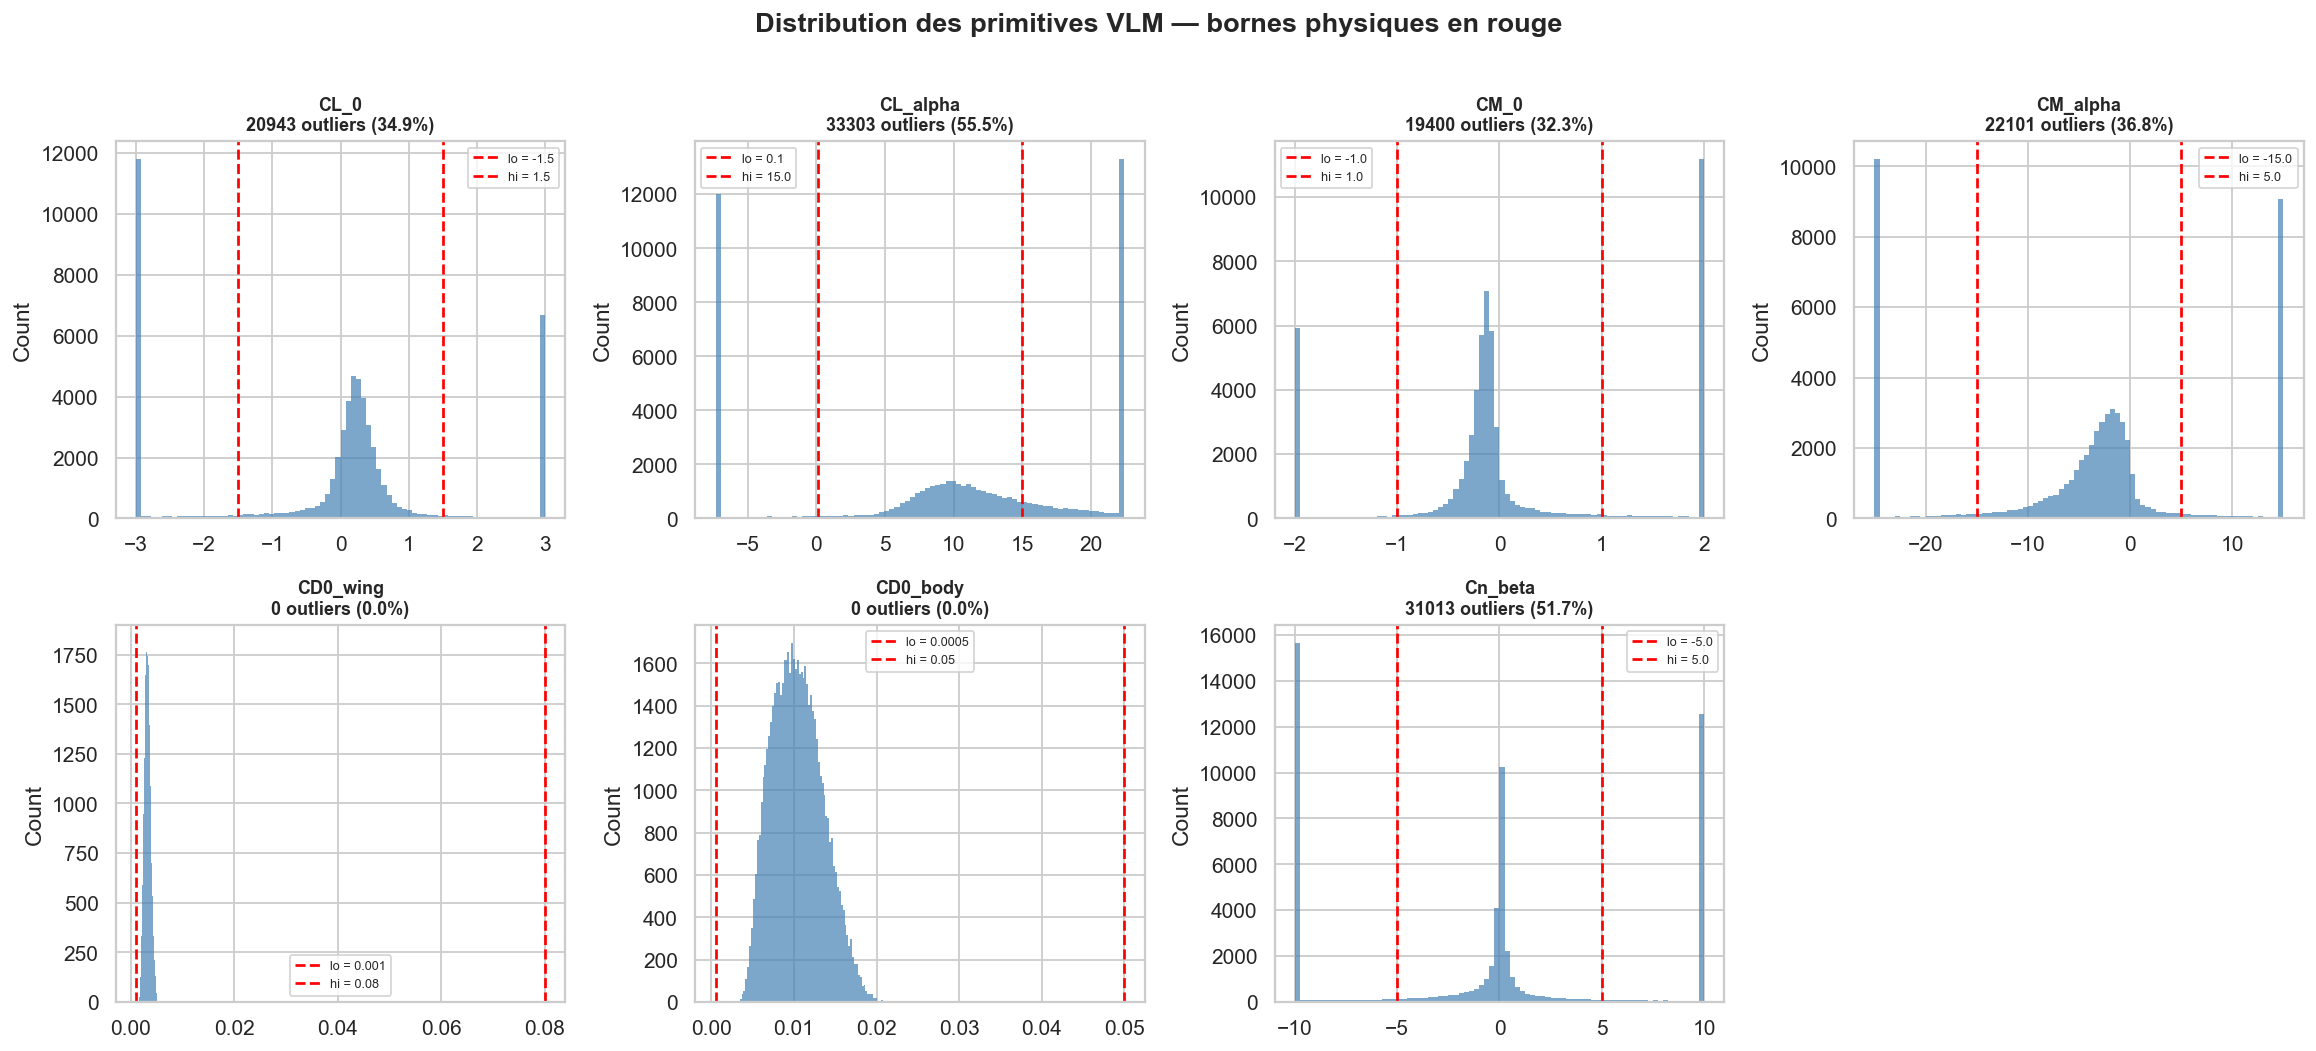

In [5]:
# ── Histogrammes : distribution brute vs bornes physiques ──
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flat

for i, key in enumerate(PRIMITIVE_TARGETS):
    ax = axes[i]
    vals = df_Y[key].values
    lo, hi = _TARGET_CLIP[key]

    # Clamp pour la visualisation (sinon les outliers écrasent l'histogramme)
    vals_clamp = np.clip(vals, lo - 0.5 * (hi - lo), hi + 0.5 * (hi - lo))

    ax.hist(vals_clamp, bins=80, alpha=0.7, edgecolor="none", color="steelblue")
    ax.axvline(lo, color="red", ls="--", lw=1.5, label=f"lo = {lo}")
    ax.axvline(hi, color="red", ls="--", lw=1.5, label=f"hi = {hi}")

    n_out = outlier_masks[key].sum()
    pct = 100 * n_out / len(vals)
    ax.set_title(f"{key}\n{n_out} outliers ({pct:.1f}%)", fontweight="bold", fontsize=10)
    ax.legend(fontsize=7)
    ax.set_ylabel("Count")

axes[7].set_visible(False)
fig.suptitle("Distribution des primitives VLM — bornes physiques en rouge", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

Samples outlier sur au moins 1 primitive : 39070 / 60000 (65.1%)

Distribution du nombre de primitives en outlier par sample :
  0 primitives en outlier : 20930 samples (34.9%)
  1 primitives en outlier : 11273 samples (18.8%)
  2 primitives en outlier : 4904 samples (8.2%)
  3 primitives en outlier : 3225 samples (5.4%)
  4 primitives en outlier : 2336 samples (3.9%)
  5 primitives en outlier : 17332 samples (28.9%)


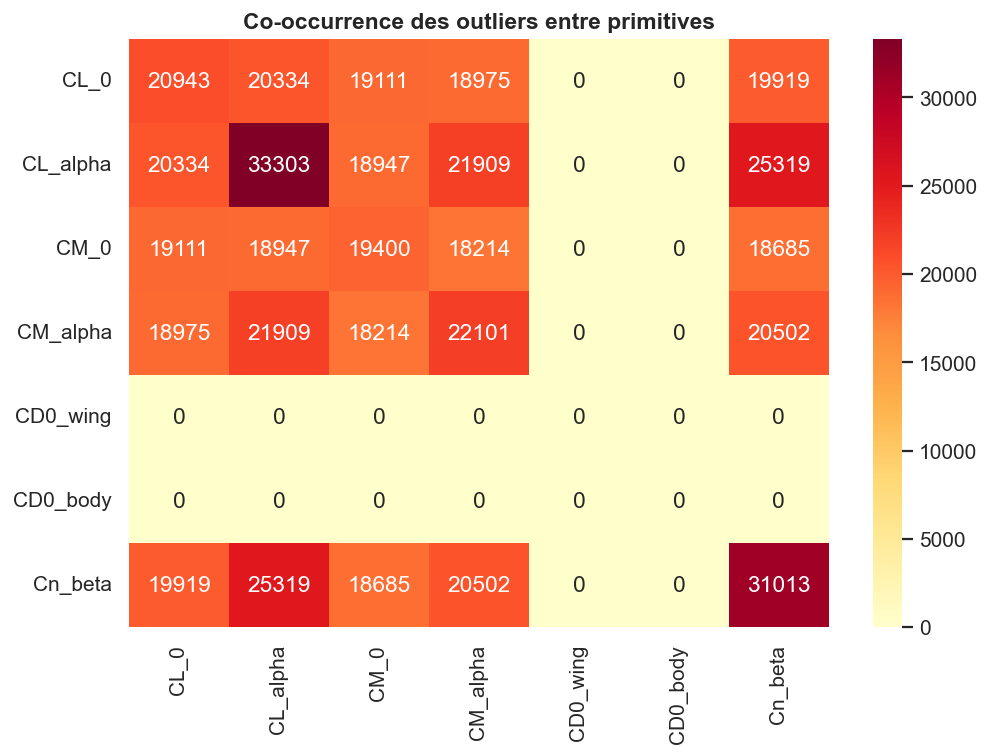

In [6]:
# ── Matrice de co-occurrence des outliers ──
# Un sample peut être outlier sur plusieurs primitives à la fois
outlier_df = pd.DataFrame(outlier_masks)
outlier_any = outlier_df.any(axis=1)
print(f"Samples outlier sur au moins 1 primitive : {outlier_any.sum()} / {len(outlier_any)} "
      f"({100*outlier_any.mean():.1f}%)")

# Nombre de primitives en outlier par sample
n_outlier_per_sample = outlier_df.sum(axis=1)
print(f"\nDistribution du nombre de primitives en outlier par sample :")
for n in range(8):
    count = (n_outlier_per_sample == n).sum()
    if count > 0:
        print(f"  {n} primitives en outlier : {count} samples ({100*count/len(n_outlier_per_sample):.1f}%)")

# Matrice de co-occurrence
cooccurrence = outlier_df.astype(int).T @ outlier_df.astype(int)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cooccurrence, annot=True, fmt="d", cmap="YlOrRd", ax=ax,
            xticklabels=PRIMITIVE_TARGETS, yticklabels=PRIMITIVE_TARGETS)
ax.set_title("Co-occurrence des outliers entre primitives", fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Caractérisation des géométries divergentes

Quelles variables de design provoquent la divergence VLM ?
On compare la distribution des variables entre samples propres et outliers.

In [7]:
# ── Test statistique : quelles variables discriminent clean vs outlier ? ──
from scipy.stats import ks_2samp

mask_clean = ~outlier_any.values
mask_outlier = outlier_any.values

print(f"Clean: {mask_clean.sum()} | Outlier: {mask_outlier.sum()}\n")
print(f"{'Variable':<28} {'KS stat':>8} {'p-value':>12} {'Mean clean':>12} {'Mean outlier':>13} {'Shift':>8}")
print("-" * 85)

ks_results = []
for j, var in enumerate(VAR_NAMES):
    v_clean = X_raw[mask_clean, j]
    v_outlier = X_raw[mask_outlier, j]
    stat, pval = ks_2samp(v_clean, v_outlier)
    shift = v_outlier.mean() - v_clean.mean()
    ks_results.append((var, stat, pval, v_clean.mean(), v_outlier.mean(), shift))
    flag = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
    print(f"{var:<28} {stat:>8.4f} {pval:>12.2e} {v_clean.mean():>12.4f} {v_outlier.mean():>13.4f} {shift:>+8.4f} {flag}")

print("\n*** p<0.001  ** p<0.01  * p<0.05")

Clean: 20930 | Outlier: 39070

Variable                      KS stat      p-value   Mean clean  Mean outlier    Shift
-------------------------------------------------------------------------------------
half_span                      0.0340     3.98e-14       0.7771        0.7739  -0.0033 ***
wing_root_chord                0.2605     0.00e+00       0.3671        0.4176  +0.0505 ***
taper_ratio                    0.1093    2.87e-142       0.2254        0.2478  +0.0225 ***
le_sweep_deg                   0.0144     7.20e-03      26.5553       26.4704  -0.0849 **
body_chord_ratio               0.0134     1.47e-02       1.5490        1.5505  +0.0015 *
body_halfwidth                 0.4261     0.00e+00       0.1946        0.1492  -0.0454 ***
body_tc_root                   0.0105     9.87e-02       0.1846        0.1852  +0.0006 
body_camber                    0.0467     2.59e-26       0.0340        0.0355  +0.0015 ***
body_reflex                    0.0416     5.79e-21       0.0317        0.0

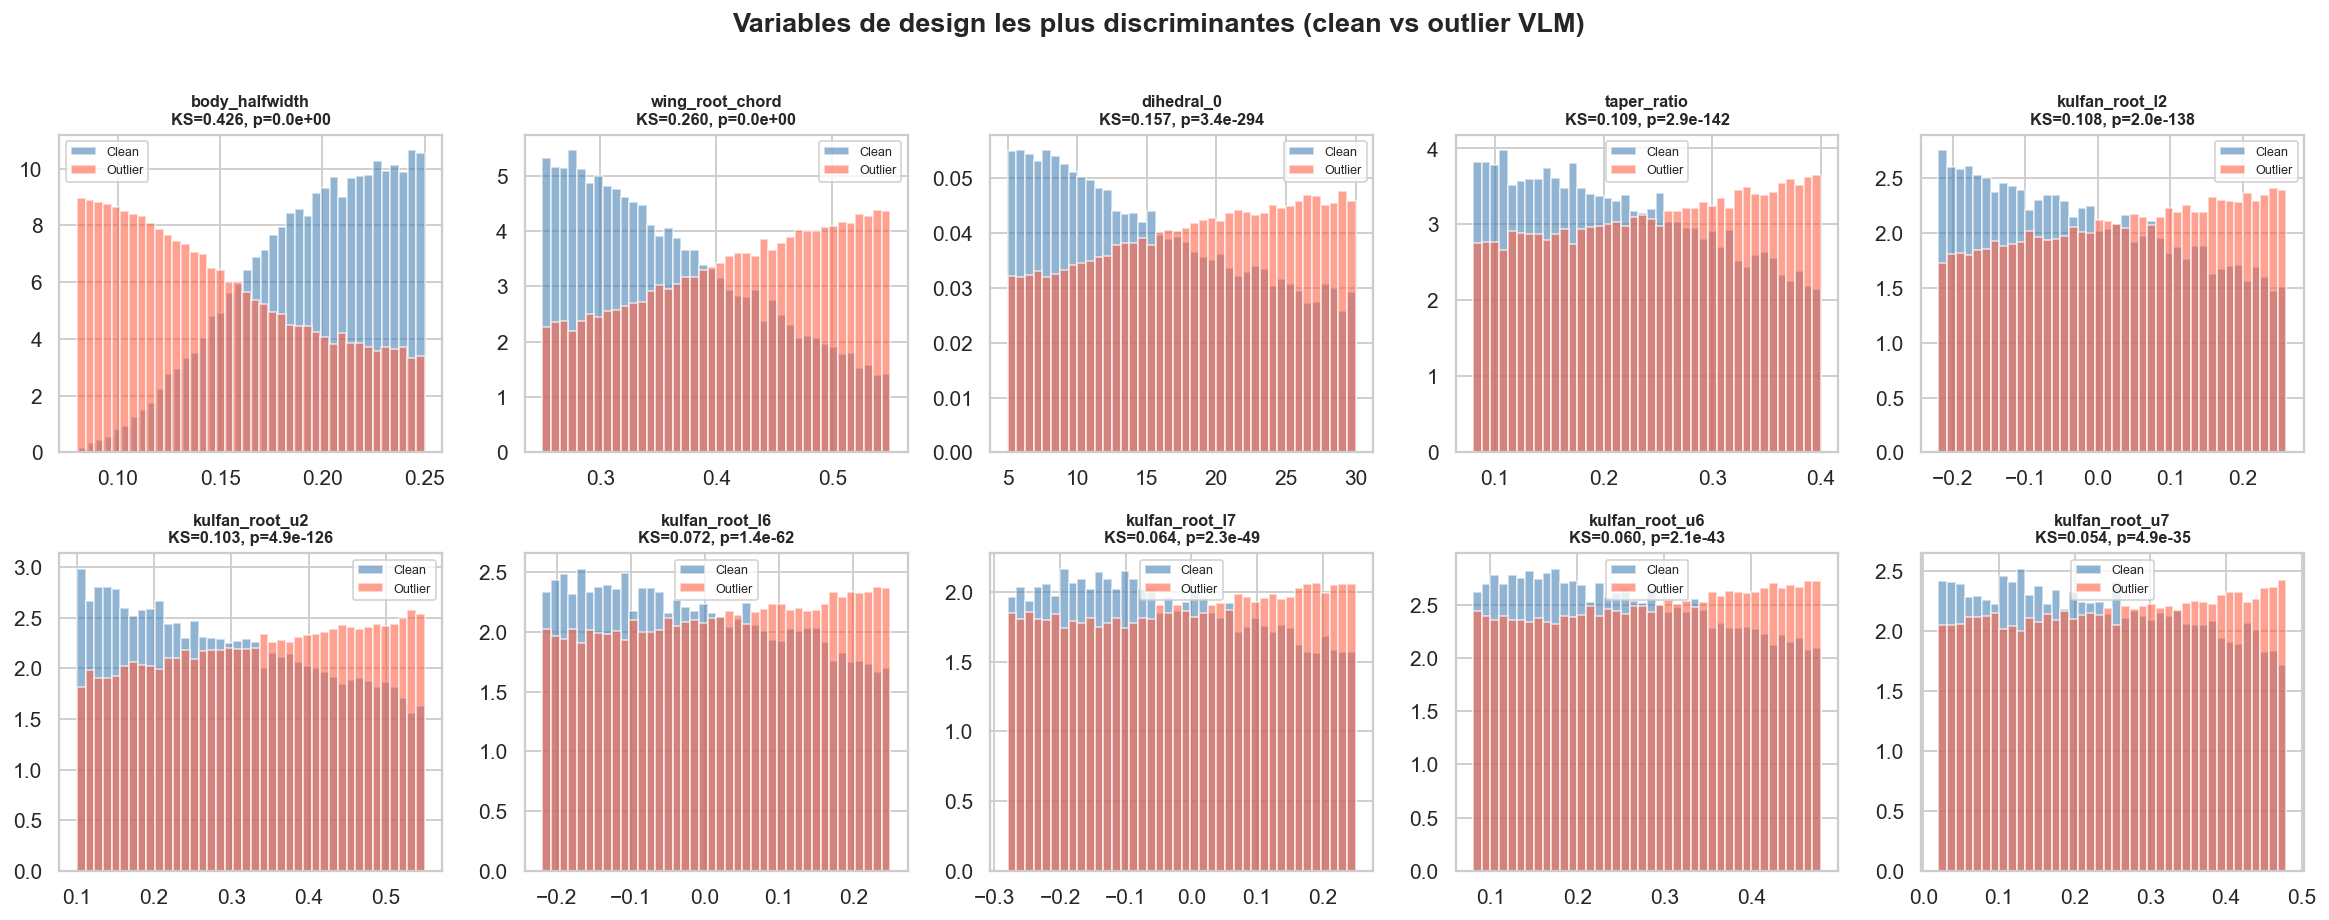

In [8]:
# ── Top variables les plus discriminantes (KS > seuil) ──
ks_sorted = sorted(ks_results, key=lambda x: x[1], reverse=True)
top_vars = [v for v in ks_sorted if v[2] < 0.01][:10]

if top_vars:
    fig, axes = plt.subplots(2, min(5, len(top_vars)), figsize=(18, 7))
    axes = axes.flat if len(top_vars) > 1 else [axes]

    for i, (var, stat, pval, _, _, _) in enumerate(top_vars[:min(10, len(axes))]):
        ax = axes[i]
        j = VAR_NAMES.index(var)
        ax.hist(X_raw[mask_clean, j], bins=40, alpha=0.6, label="Clean", density=True, color="steelblue")
        ax.hist(X_raw[mask_outlier, j], bins=40, alpha=0.6, label="Outlier", density=True, color="tomato")
        ax.set_title(f"{var}\nKS={stat:.3f}, p={pval:.1e}", fontsize=9, fontweight="bold")
        ax.legend(fontsize=7)

    for i in range(len(top_vars), len(axes)):
        axes[i].set_visible(False)

    fig.suptitle("Variables de design les plus discriminantes (clean vs outlier VLM)", fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("Aucune variable significativement discriminante (p < 0.01)")

## 4. Filtrage et constitution du dataset propre

On applique le filtre `_TARGET_CLIP` sur les 7 primitives simultanément :
un sample est conservé uniquement si **toutes** ses primitives sont dans les bornes physiques.

In [9]:
# ── Application du filtre global ──
mask_all_clean = np.ones(len(df_Y), dtype=bool)
for key in PRIMITIVE_TARGETS:
    lo, hi = _TARGET_CLIP[key]
    vals = df_Y[key].values
    mask_all_clean &= (vals >= lo) & (vals <= hi)

n_clean = mask_all_clean.sum()
n_rejected = len(df_Y) - n_clean
print(f"Samples propres (toutes primitives in bounds) : {n_clean} / {len(df_Y)} ({100*n_clean/len(df_Y):.1f}%)")
print(f"Samples rejetés : {n_rejected} ({100*n_rejected/len(df_Y):.1f}%)")

X_clean = X_raw[mask_all_clean]
Y_clean = df_Y.values[mask_all_clean]
results_clean = [r for r, m in zip(results, mask_all_clean) if m]

df_X_clean = pd.DataFrame(X_clean, columns=VAR_NAMES)
df_Y_clean = pd.DataFrame(Y_clean, columns=PRIMITIVE_TARGETS)

print(f"\nDataset propre : X={X_clean.shape}, Y={Y_clean.shape}")

Samples propres (toutes primitives in bounds) : 20930 / 60000 (34.9%)
Samples rejetés : 39070 (65.1%)

Dataset propre : X=(20930, 30), Y=(20930, 7)


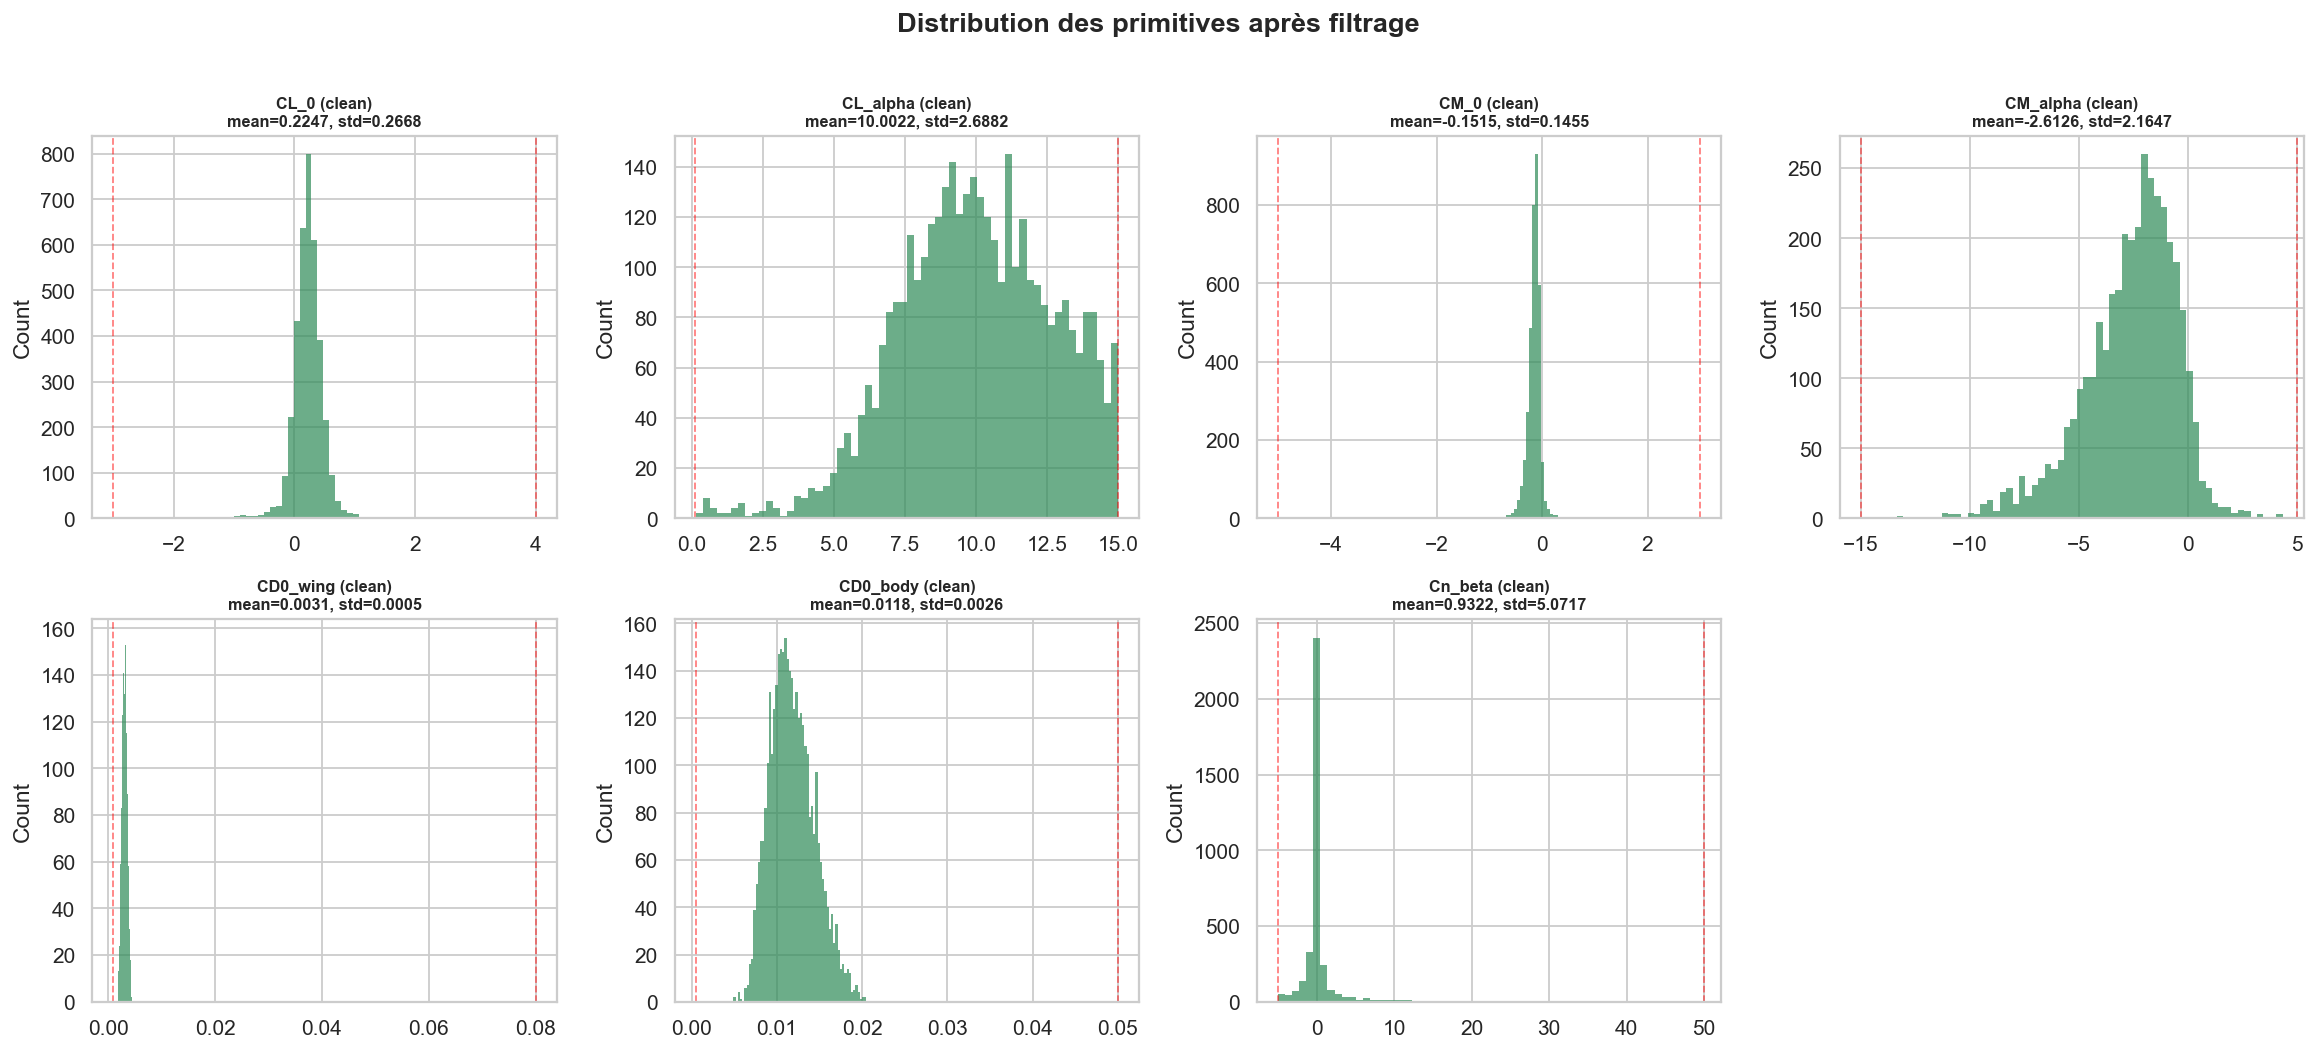

In [10]:
# ── Distributions des primitives APRÈS filtrage ──
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flat

for i, key in enumerate(PRIMITIVE_TARGETS):
    ax = axes[i]
    vals = df_Y_clean[key].values
    lo, hi = _TARGET_CLIP[key]

    ax.hist(vals, bins=60, alpha=0.7, edgecolor="none", color="seagreen")
    ax.axvline(lo, color="red", ls="--", lw=1, alpha=0.5)
    ax.axvline(hi, color="red", ls="--", lw=1, alpha=0.5)

    ax.set_title(f"{key} (clean)\nmean={vals.mean():.4f}, std={vals.std():.4f}", fontsize=9, fontweight="bold")
    ax.set_ylabel("Count")

axes[7].set_visible(False)
fig.suptitle("Distribution des primitives après filtrage", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [10]:
# ── Détection d'outliers résiduels par IQR sur le dataset propre ──
print("── Outliers résiduels (IQR × 3) sur dataset propre ──\n")
print(f"{'Cible':<12} {'Q1':>10} {'Q3':>10} {'IQR':>10} {'N mild (1.5×)':>14} {'N extrême (3×)':>15}")
print("-" * 75)

for key in PRIMITIVE_TARGETS:
    vals = df_Y_clean[key].values
    q1, q3 = np.percentile(vals, [25, 75])
    iqr = q3 - q1
    mild = ((vals < q1 - 1.5 * iqr) | (vals > q3 + 1.5 * iqr)).sum()
    extreme = ((vals < q1 - 3 * iqr) | (vals > q3 + 3 * iqr)).sum()
    print(f"{key:<12} {q1:>10.4f} {q3:>10.4f} {iqr:>10.4f} {mild:>14} {extreme:>15}")

── Outliers résiduels (IQR × 3) sur dataset propre ──

Cible                Q1         Q3        IQR  N mild (1.5×)  N extrême (3×)
---------------------------------------------------------------------------
CL_0             0.0978     0.3539     0.2561            513              91
CL_alpha         8.2568    11.9540     3.6972            179               0
CM_0            -0.2057    -0.0859     0.1198            932             194
CM_alpha        -3.7506    -1.1258     2.6248            621              29
CD0_wing         0.0027     0.0034     0.0007             26               0
CD0_body         0.0100     0.0136     0.0036             98               0
Cn_beta         -0.1895     0.1548     0.3443           5059            3396


## 5. Feature augmentation & analyse des corrélations

In [11]:
# ── Feature augmentation (30 → 52) ──
X_aug = augment_features(X_clean)
print(f"Features augmentées : {X_clean.shape[1]} → {X_aug.shape[1]}")

AUG_NAMES = VAR_NAMES + [
    "wing_area", "aspect_ratio", "mac", "tip_chord", "body_root_chord",
    "outer_span", "total_twist", "twist_gradient", "mean_twist",
    "effective_span", "qc_sweep", "reflex_root", "camber_root",
    "ac_offset", "taper_elliptic_dev", "body_volume", "body_frontal_area",
    "body_wetted_area", "body_aspect_ratio", "blend_tc_mismatch",
    "body_sweep_total", "span_body_ratio",
]

df_aug = pd.DataFrame(X_aug, columns=AUG_NAMES)

# Vérification : pas de NaN ou Inf dans les features augmentées
n_nan = np.isnan(X_aug).sum()
n_inf = np.isinf(X_aug).sum()
print(f"NaN dans features augmentées : {n_nan}")
print(f"Inf dans features augmentées : {n_inf}")

df_aug.describe().round(4)

Features augmentées : 30 → 52
NaN dans features augmentées : 0
Inf dans features augmentées : 0


,half_span,wing_root_chord,taper_ratio,le_sweep_deg,body_chord_ratio,body_halfwidth,body_tc_root,body_camber,body_reflex,body_twist,...,camber_root,ac_offset,taper_elliptic_dev,body_volume,body_frontal_area,body_wetted_area,body_aspect_ratio,blend_tc_mismatch,body_sweep_total,span_body_ratio
count,20930.0000,20930.0000,20930.0000,20930.0000,20930.0000,20930.0000,20930.0000,20930.0000,20930.0000,20930.0000,...,20930.0000,20930.0000,20930.0000,20930.0000,20930.0000,20930.0000,20930.0000,20930.0000,20930.0000,20930.0000
mean,0.7771,0.3671,0.2254,26.5553,1.5490,0.1946,0.1846,0.0340,0.0317,1.8839,...,0.3024,0.1797,0.1746,0.0096,0.1048,0.3737,0.8777,0.0796,34.0800,0.2557
std,0.1260,0.0807,0.0903,4.9256,0.2563,0.0371,0.0377,0.0142,0.0286,2.2497,...,0.1857,0.0400,0.0903,0.0039,0.0360,0.1181,0.2632,0.0377,6.5437,0.0606
min,0.5500,0.2500,0.0800,18.0004,1.1000,0.0811,0.1200,0.0100,-0.0200,-1.9999,...,-0.1143,0.0878,0.0000,0.0019,0.0336,0.1012,0.2689,0.0150,18.0952,0.0953
25%,0.6709,0.2984,0.1473,22.2653,1.3306,0.1686,0.1516,0.0217,0.0071,-0.0401,...,0.1655,0.1495,0.1002,0.0068,0.0782,0.2870,0.6821,0.0466,29.3889,0.2111
50%,0.7773,0.3538,0.2190,26.6032,1.5480,0.1994,0.1847,0.0336,0.0326,1.8443,...,0.3015,0.1759,0.1810,0.0089,0.0991,0.3581,0.8455,0.0797,34.1342,0.2496
75%,0.8839,0.4276,0.2998,30.8408,1.7691,0.2256,0.2172,0.0460,0.0566,3.7633,...,0.4337,0.2064,0.2527,0.0118,0.1254,0.4464,1.0434,0.1122,38.8479,0.2950
max,1.0000,0.5500,0.4000,34.9998,2.0000,0.2500,0.2500,0.0600,0.0800,5.9995,...,0.8006,0.3386,0.3200,0.0302,0.2666,0.8331,1.8449,0.1450,49.8876,0.4504


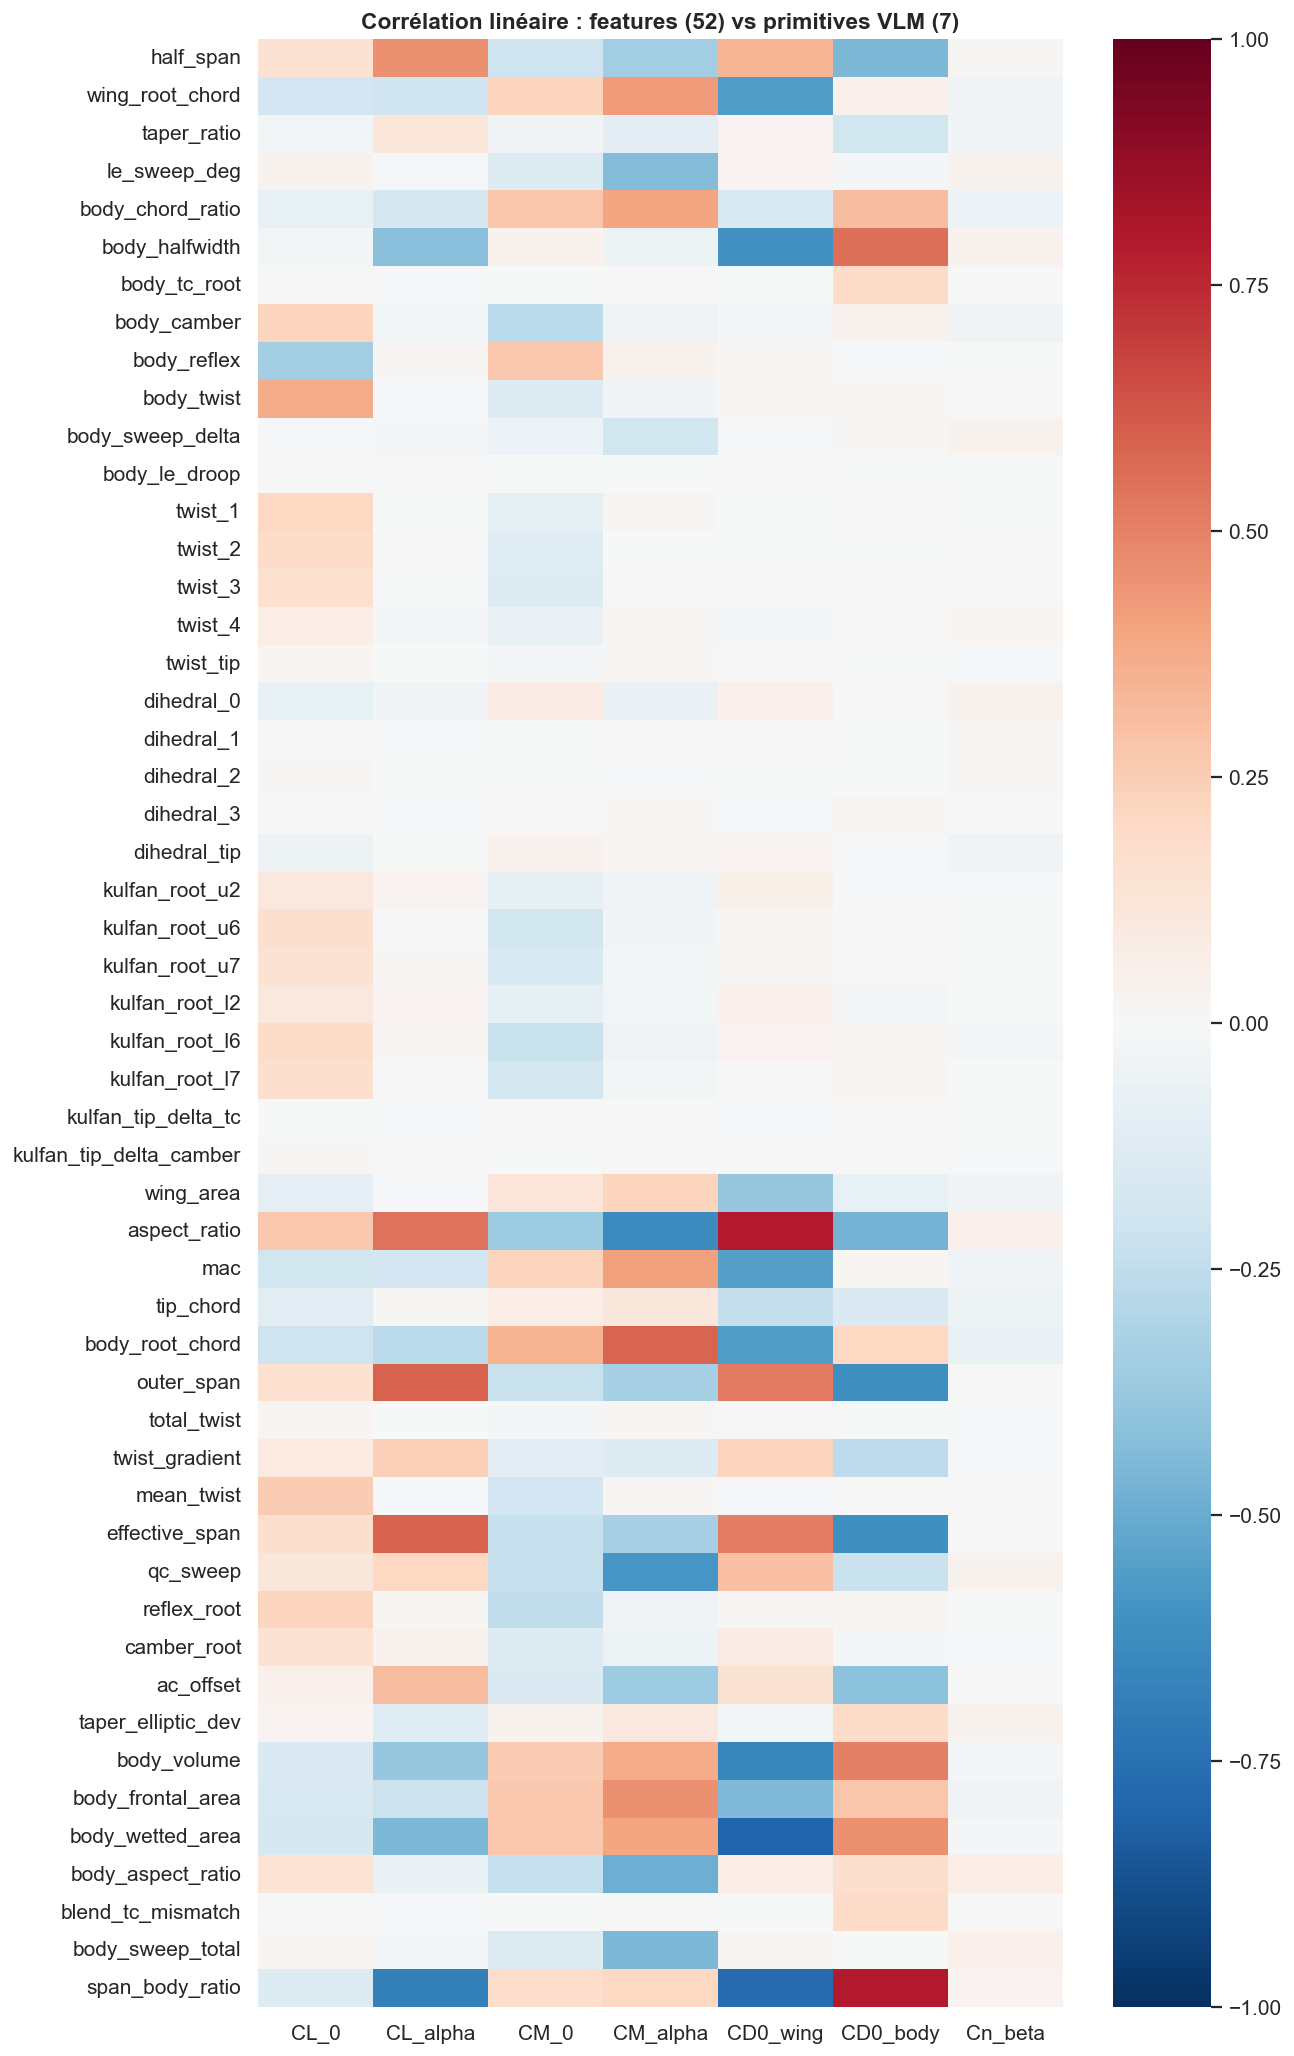

In [12]:
# ── Corrélation features augmentées ↔ primitives VLM ──
corr_matrix = np.zeros((len(AUG_NAMES), len(PRIMITIVE_TARGETS)))
for i, fname in enumerate(AUG_NAMES):
    for j, tname in enumerate(PRIMITIVE_TARGETS):
        corr_matrix[i, j] = np.corrcoef(X_aug[:, i], Y_clean[:, j])[0, 1]

# Top 15 features les plus corrélées par primitive
fig, ax = plt.subplots(figsize=(10, 16))
sns.heatmap(corr_matrix, xticklabels=PRIMITIVE_TARGETS, yticklabels=AUG_NAMES,
            cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax, annot=False)
ax.set_title("Corrélation linéaire : features (52) vs primitives VLM (7)", fontweight="bold")
plt.tight_layout()
plt.show()

In [13]:
# ── Top 5 features les plus corrélées pour chaque primitive ──
print("── Top 5 features par primitive (|corrélation| max) ──\n")
for j, tname in enumerate(PRIMITIVE_TARGETS):
    corrs = corr_matrix[:, j]
    top_idx = np.argsort(np.abs(corrs))[::-1][:5]
    print(f"{tname}:")
    for idx in top_idx:
        print(f"  {AUG_NAMES[idx]:<28} r = {corrs[idx]:+.4f}")
    print()

── Top 5 features par primitive (|corrélation| max) ──

CL_0:
  body_twist                   r = +0.3732
  body_reflex                  r = -0.3448
  aspect_ratio                 r = +0.2681
  mean_twist                   r = +0.2555
  body_camber                  r = +0.2261

CL_alpha:
  span_body_ratio              r = -0.6829
  outer_span                   r = +0.5916
  effective_span               r = +0.5885
  aspect_ratio                 r = +0.5424
  half_span                    r = +0.4600

CM_0:
  aspect_ratio                 r = -0.3660
  body_root_chord              r = +0.3490
  body_chord_ratio             r = +0.2738
  body_reflex                  r = +0.2719
  body_camber                  r = -0.2706

CM_alpha:
  aspect_ratio                 r = -0.6344
  qc_sweep                     r = -0.5892
  body_root_chord              r = +0.5800
  body_aspect_ratio            r = -0.4896
  body_frontal_area            r = +0.4572

CD0_wing:
  body_wetted_area             r = -0.

In [14]:
# ── Corrélation inter-features (détection de multicolinéarité) ──
corr_feat = df_aug.corr()

# Paires à forte colinéarité (|r| > 0.95)
high_corr_pairs = []
for i in range(len(AUG_NAMES)):
    for j in range(i + 1, len(AUG_NAMES)):
        r = corr_feat.iloc[i, j]
        if abs(r) > 0.95:
            high_corr_pairs.append((AUG_NAMES[i], AUG_NAMES[j], r))

high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
print(f"Paires de features avec |r| > 0.95 : {len(high_corr_pairs)}\n")
for f1, f2, r in high_corr_pairs:
    print(f"  {f1:<28} ↔ {f2:<28} r = {r:+.4f}")

if not high_corr_pairs:
    print("  Aucune paire fortement colinéaire.")

Paires de features avec |r| > 0.95 : 6

  taper_ratio                  ↔ taper_elliptic_dev           r = -1.0000
  twist_tip                    ↔ total_twist                  r = +1.0000
  body_tc_root                 ↔ blend_tc_mismatch            r = +1.0000
  wing_root_chord              ↔ mac                          r = +0.9908
  outer_span                   ↔ effective_span               r = +0.9869
  half_span                    ↔ outer_span                   r = +0.9561


## 6. Couverture du design space

Vérifie que le dataset propre couvre bien l'espace de design (pas de trous après filtrage)
et que le LHS n'est pas biaisé.

In [15]:
# ── Couverture des bornes : ratio (range observé) / (range théorique) ──
lb = np.array([BOUNDS[v][0] for v in VAR_NAMES])
ub = np.array([BOUNDS[v][1] for v in VAR_NAMES])
design_range = ub - lb

print(f"{'Variable':<28} {'Borne lo':>9} {'Borne hi':>9} {'Min clean':>10} {'Max clean':>10} {'Couverture':>11}")
print("-" * 80)

coverage_pcts = []
for j, var in enumerate(VAR_NAMES):
    v = X_clean[:, j]
    obs_range = v.max() - v.min()
    coverage = obs_range / design_range[j] if design_range[j] > 0 else 1.0
    coverage_pcts.append(coverage)
    flag = " ⚠" if coverage < 0.80 else ""
    print(f"{var:<28} {lb[j]:>9.3f} {ub[j]:>9.3f} {v.min():>10.4f} {v.max():>10.4f} {100*coverage:>10.1f}%{flag}")

print(f"\nCouverture moyenne : {100*np.mean(coverage_pcts):.1f}%")
n_poor = sum(1 for c in coverage_pcts if c < 0.80)
if n_poor:
    print(f"⚠ {n_poor} variables avec couverture < 80%")

Variable                      Borne lo  Borne hi  Min clean  Max clean  Couverture
--------------------------------------------------------------------------------
half_span                        0.550     1.000     0.5500     1.0000      100.0%
wing_root_chord                  0.250     0.550     0.2500     0.5500      100.0%
taper_ratio                      0.080     0.400     0.0800     0.4000      100.0%
le_sweep_deg                    18.000    35.000    18.0004    34.9998      100.0%
body_chord_ratio                 1.100     2.000     1.1000     2.0000      100.0%
body_halfwidth                   0.080     0.250     0.0811     0.2500       99.4%
body_tc_root                     0.120     0.250     0.1200     0.2500      100.0%
body_camber                      0.010     0.060     0.0100     0.0600      100.0%
body_reflex                     -0.020     0.080    -0.0200     0.0800      100.0%
body_twist                      -2.000     6.000    -1.9999     5.9995      100.0%
body_s

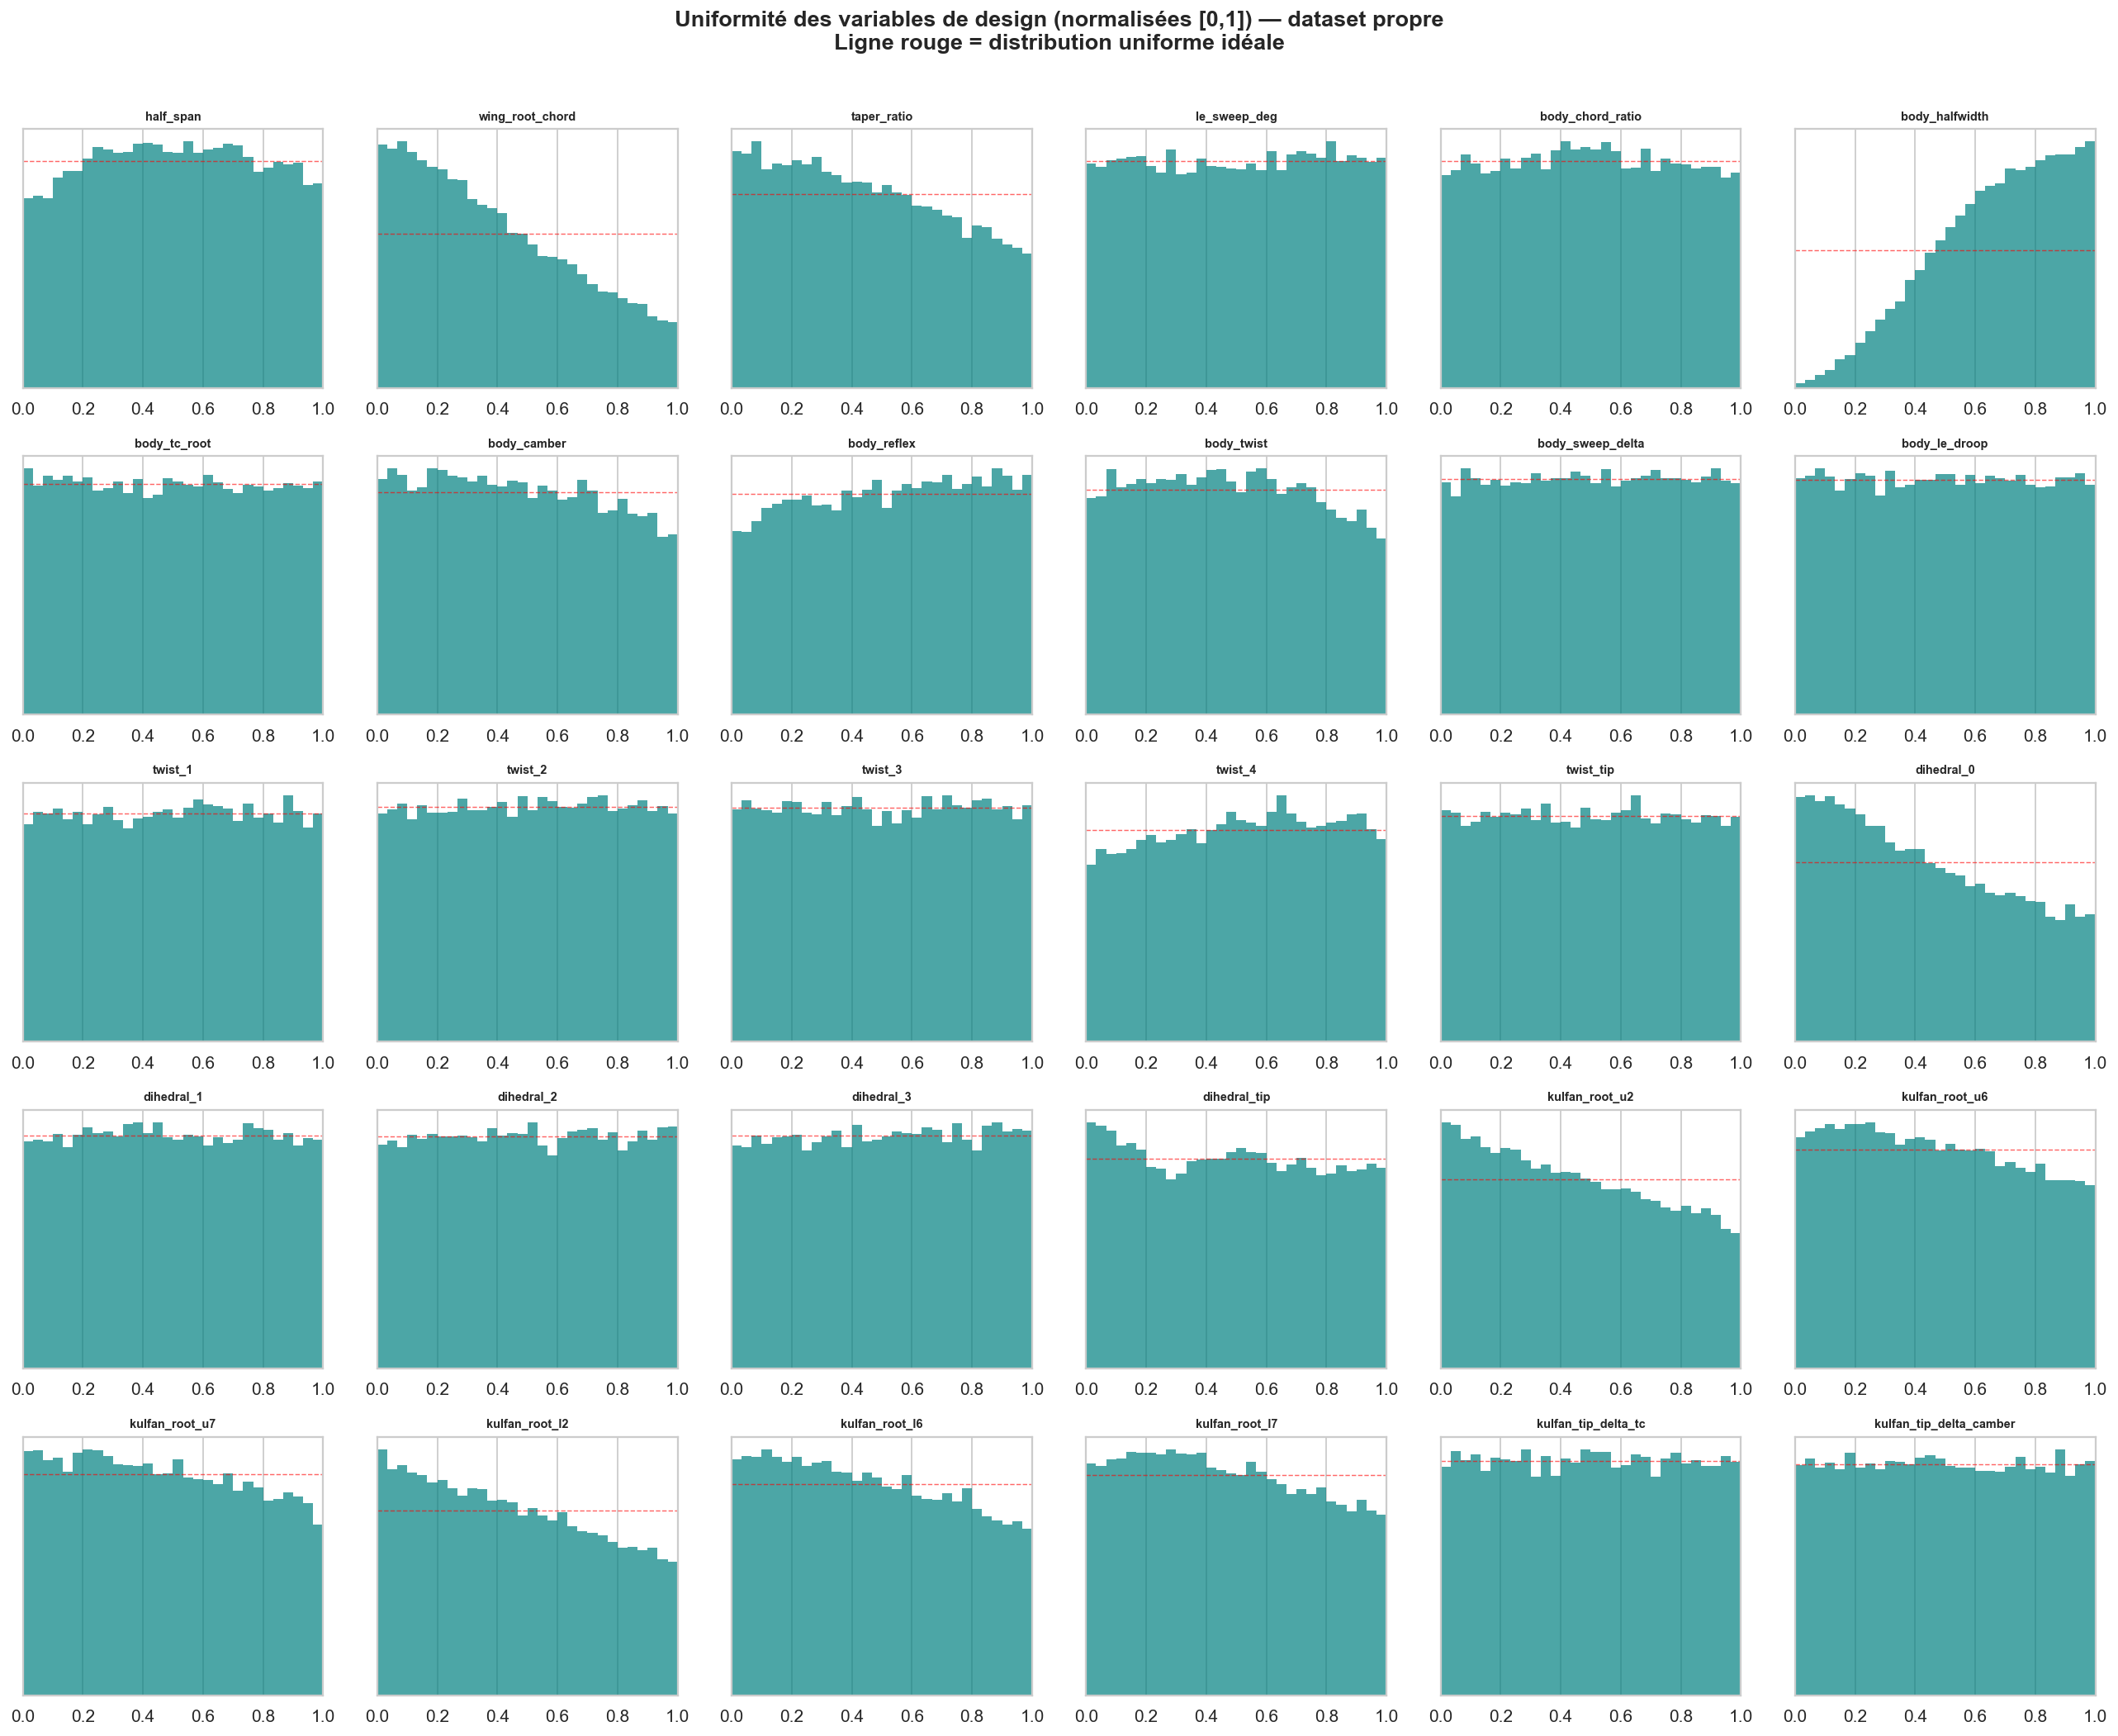

In [16]:
# ── Uniformité : histogrammes normalisés des variables de design (clean) ──
from sklearn.preprocessing import MinMaxScaler

X_norm = MinMaxScaler().fit_transform(X_clean)

fig, axes = plt.subplots(5, 6, figsize=(20, 16))
axes = axes.flat

for j in range(N_VARS):
    ax = axes[j]
    ax.hist(X_norm[:, j], bins=30, alpha=0.7, edgecolor="none", color="teal", density=True)
    ax.axhline(1.0, color="red", ls="--", lw=0.8, alpha=0.6, label="Uniforme idéal")
    ax.set_title(VAR_NAMES[j], fontsize=8, fontweight="bold")
    ax.set_xlim(0, 1)
    ax.set_yticks([])

for j in range(N_VARS, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Uniformité des variables de design (normalisées [0,1]) — dataset propre\n"
             "Ligne rouge = distribution uniforme idéale", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

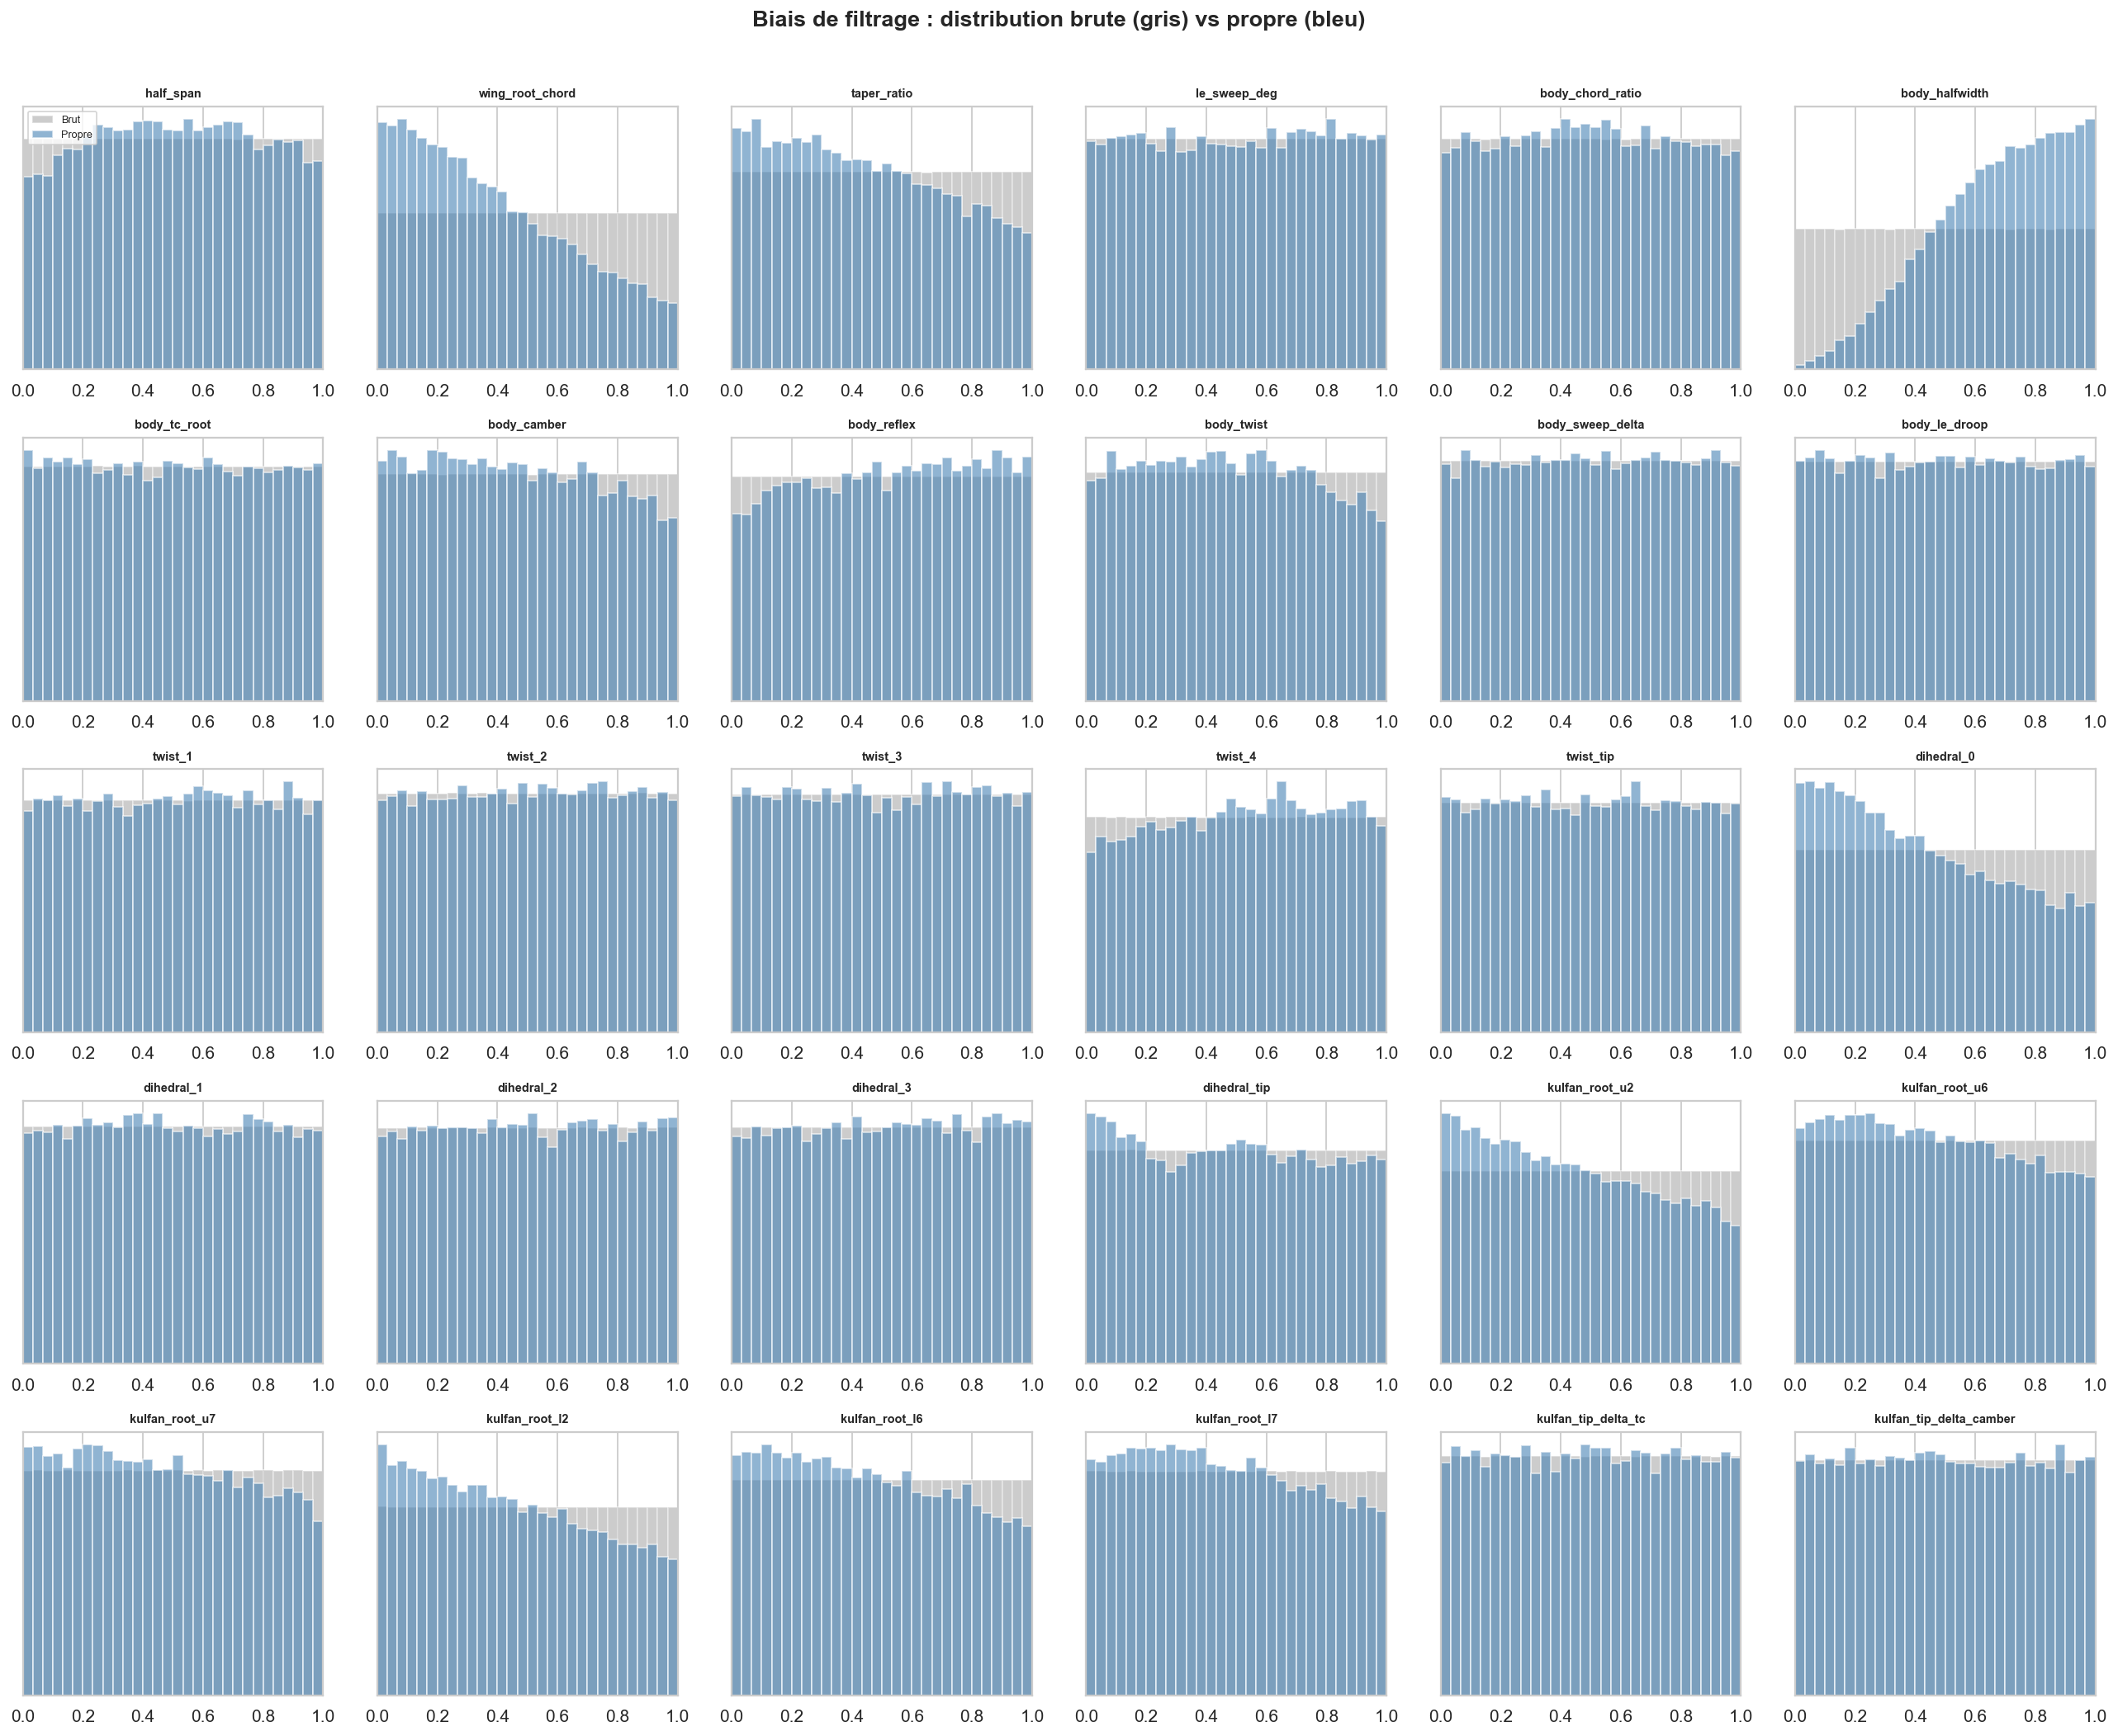

In [17]:
# ── Biais de filtrage : quelles zones du design space sont sur-représentées/sous-représentées ? ──
# Compare la densité marginale avant/après filtrage pour chaque variable
fig, axes = plt.subplots(5, 6, figsize=(20, 16))
axes = axes.flat

X_norm_all = MinMaxScaler().fit_transform(X_raw)
X_norm_clean = MinMaxScaler().fit_transform(X_clean)

for j in range(N_VARS):
    ax = axes[j]
    ax.hist(X_norm_all[:, j], bins=30, alpha=0.4, density=True, color="gray", label="Brut")
    ax.hist(X_norm_clean[:, j], bins=30, alpha=0.6, density=True, color="steelblue", label="Propre")
    ax.set_title(VAR_NAMES[j], fontsize=8, fontweight="bold")
    ax.set_xlim(0, 1)
    ax.set_yticks([])
    if j == 0:
        ax.legend(fontsize=7)

for j in range(N_VARS, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Biais de filtrage : distribution brute (gris) vs propre (bleu)", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 7. Analyse de la normalisation (StandardScaler)

Vérifie les propriétés statistiques des données normalisées telles que vues par le MLP.

In [18]:
# ── StandardScaler sur X augmenté et Y ──
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler().fit(X_aug)
scaler_Y = StandardScaler().fit(Y_clean)

X_scaled = scaler_X.transform(X_aug)
Y_scaled = scaler_Y.transform(Y_clean)

print("── Features (X) après StandardScaler ──")
print(f"{'Feature':<28} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10} {'Skew':>10} {'Kurt':>10}")
print("-" * 90)
from scipy.stats import skew, kurtosis
for j in range(X_scaled.shape[1]):
    col = X_scaled[:, j]
    name = AUG_NAMES[j] if j < len(AUG_NAMES) else f"feat_{j}"
    sk = skew(col)
    ku = kurtosis(col)
    flag = " ⚠" if abs(sk) > 2 or ku > 7 else ""
    print(f"{name:<28} {col.mean():>10.4f} {col.std():>10.4f} {col.min():>10.2f} {col.max():>10.2f} "
          f"{sk:>10.2f} {ku:>10.2f}{flag}")

print(f"\n── Targets (Y) après StandardScaler ──")
print(f"{'Target':<12} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10} {'Skew':>10} {'Kurt':>10}")
print("-" * 75)
for j, key in enumerate(PRIMITIVE_TARGETS):
    col = Y_scaled[:, j]
    sk = skew(col)
    ku = kurtosis(col)
    flag = " ⚠" if abs(sk) > 2 or ku > 7 else ""
    print(f"{key:<12} {col.mean():>10.4f} {col.std():>10.4f} {col.min():>10.2f} {col.max():>10.2f} "
          f"{sk:>10.2f} {ku:>10.2f}{flag}")

print("\n⚠ = skewness > 2 ou kurtosis > 7 (distribution non-gaussienne, potentiellement problématique pour le MLP)")

── Features (X) après StandardScaler ──
Feature                            Mean        Std        Min        Max       Skew       Kurt
------------------------------------------------------------------------------------------
half_span                       -0.0000     1.0000      -1.80       1.77      -0.01      -1.14
wing_root_chord                 -0.0000     1.0000      -1.45       2.27       0.47      -0.84
taper_ratio                      0.0000     1.0000      -1.61       1.93       0.19      -1.12
le_sweep_deg                     0.0000     1.0000      -1.74       1.71      -0.02      -1.21
body_chord_ratio                -0.0000     1.0000      -1.75       1.76       0.00      -1.16
body_halfwidth                   0.0000     1.0000      -3.06       1.49      -0.52      -0.51
body_tc_root                    -0.0000     1.0000      -1.72       1.74       0.01      -1.21
body_camber                     -0.0000     1.0000      -1.69       1.83       0.07      -1.17
body_reflex   

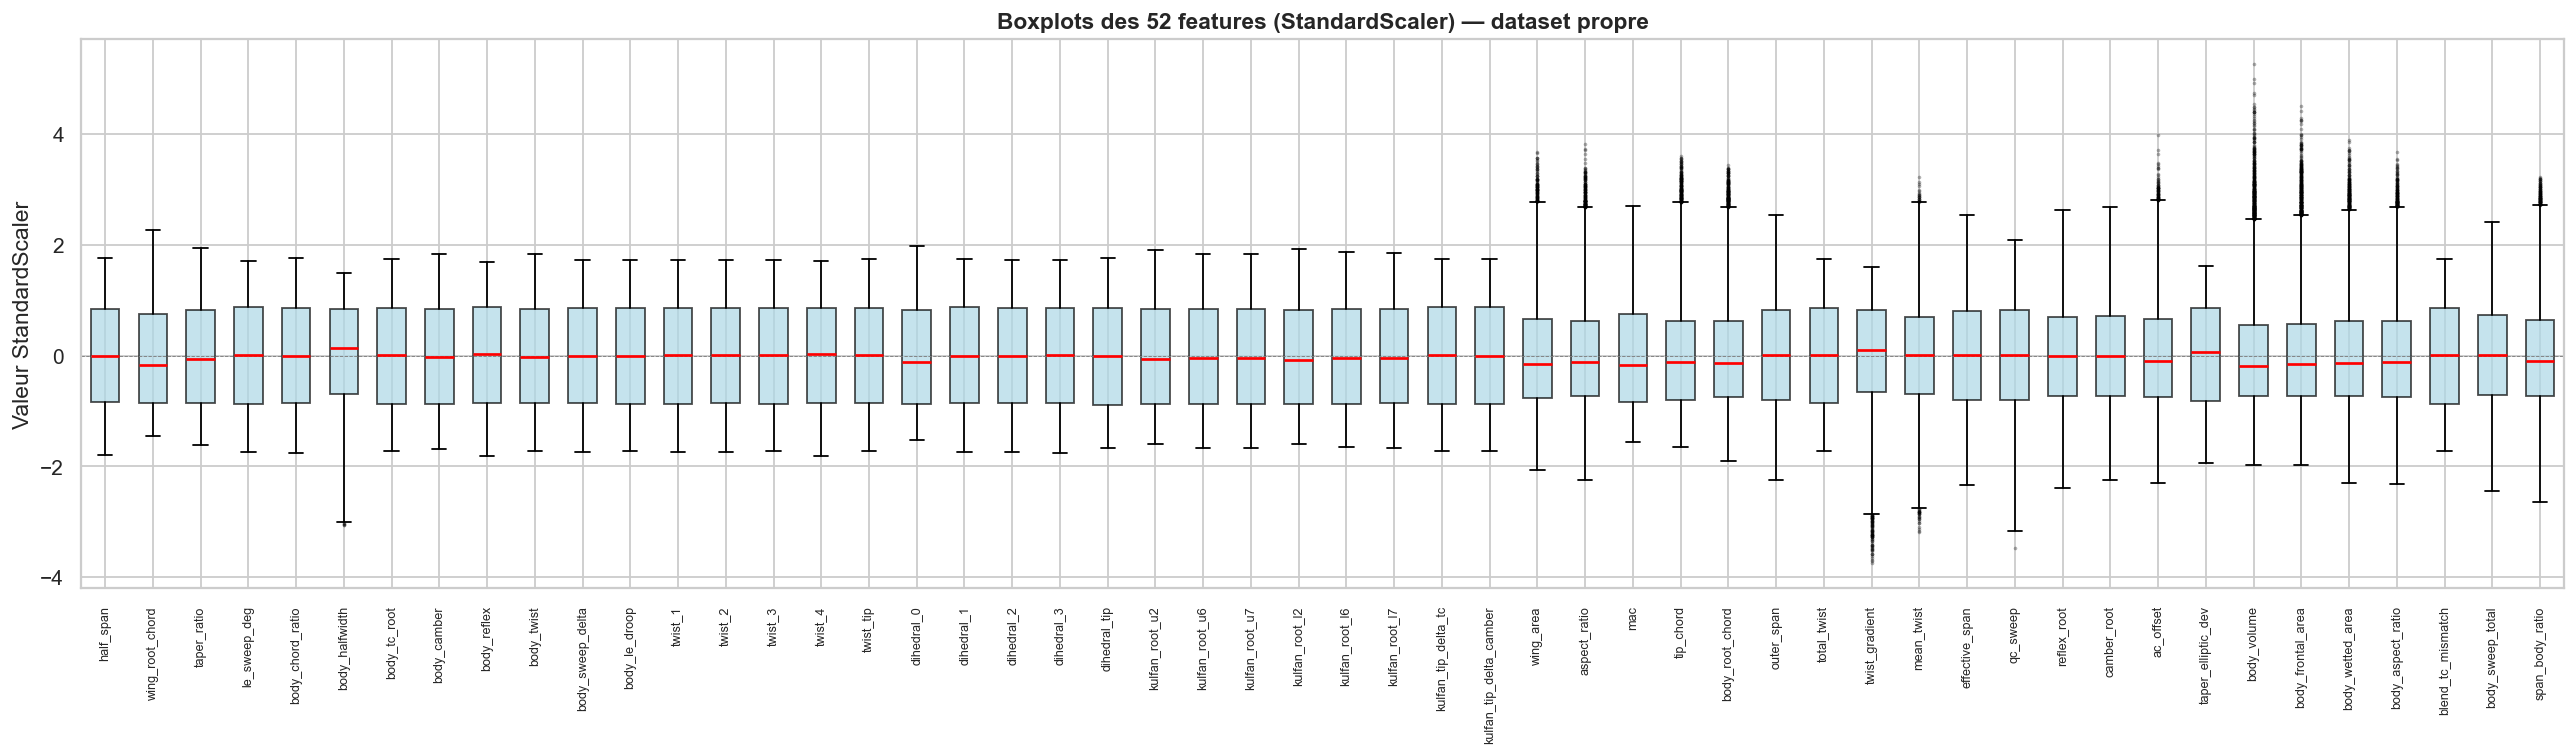

In [19]:
# ── Boxplots des features normalisées (détection visuelle d'asymétrie) ──
fig, ax = plt.subplots(figsize=(20, 6))
bp = ax.boxplot(X_scaled, vert=True, patch_artist=True, widths=0.6,
                boxprops=dict(facecolor="lightblue", alpha=0.7),
                medianprops=dict(color="red", linewidth=1.5),
                flierprops=dict(marker='.', markersize=2, alpha=0.3))

ax.set_xticks(range(1, len(AUG_NAMES) + 1))
ax.set_xticklabels(AUG_NAMES, rotation=90, fontsize=7)
ax.set_ylabel("Valeur StandardScaler")
ax.set_title("Boxplots des 52 features (StandardScaler) — dataset propre", fontweight="bold")
ax.axhline(0, color="gray", ls="--", lw=0.5)
plt.tight_layout()
plt.show()

## 8. Corrélation inter-targets et structure des primitives

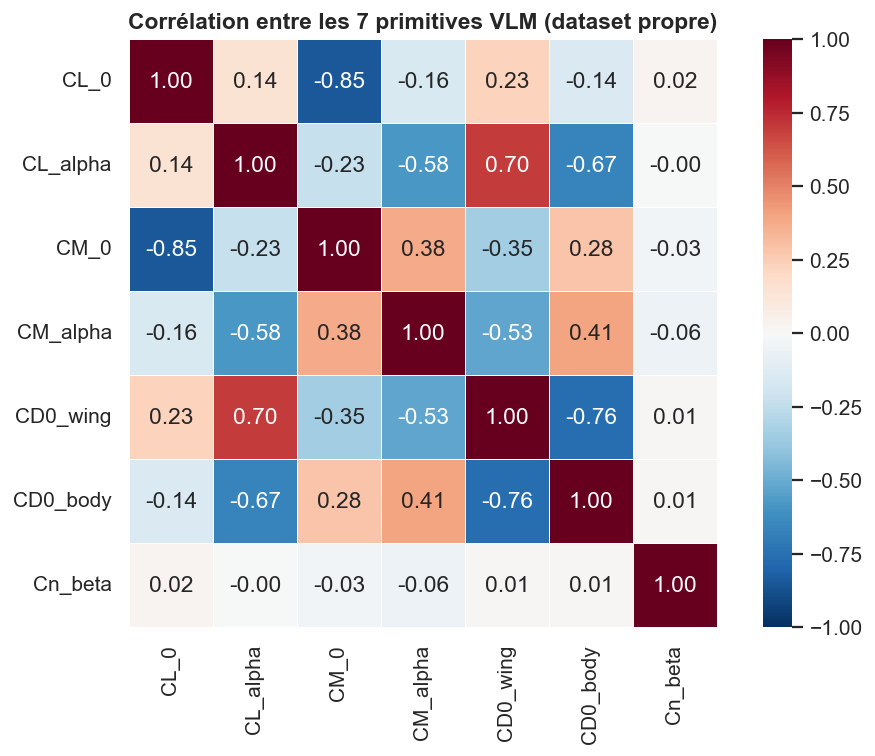

In [20]:
# ── Corrélation entre les 7 primitives ──
corr_Y = df_Y_clean.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_Y, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            ax=ax, square=True, linewidths=0.5)
ax.set_title("Corrélation entre les 7 primitives VLM (dataset propre)", fontweight="bold")
plt.tight_layout()
plt.show()

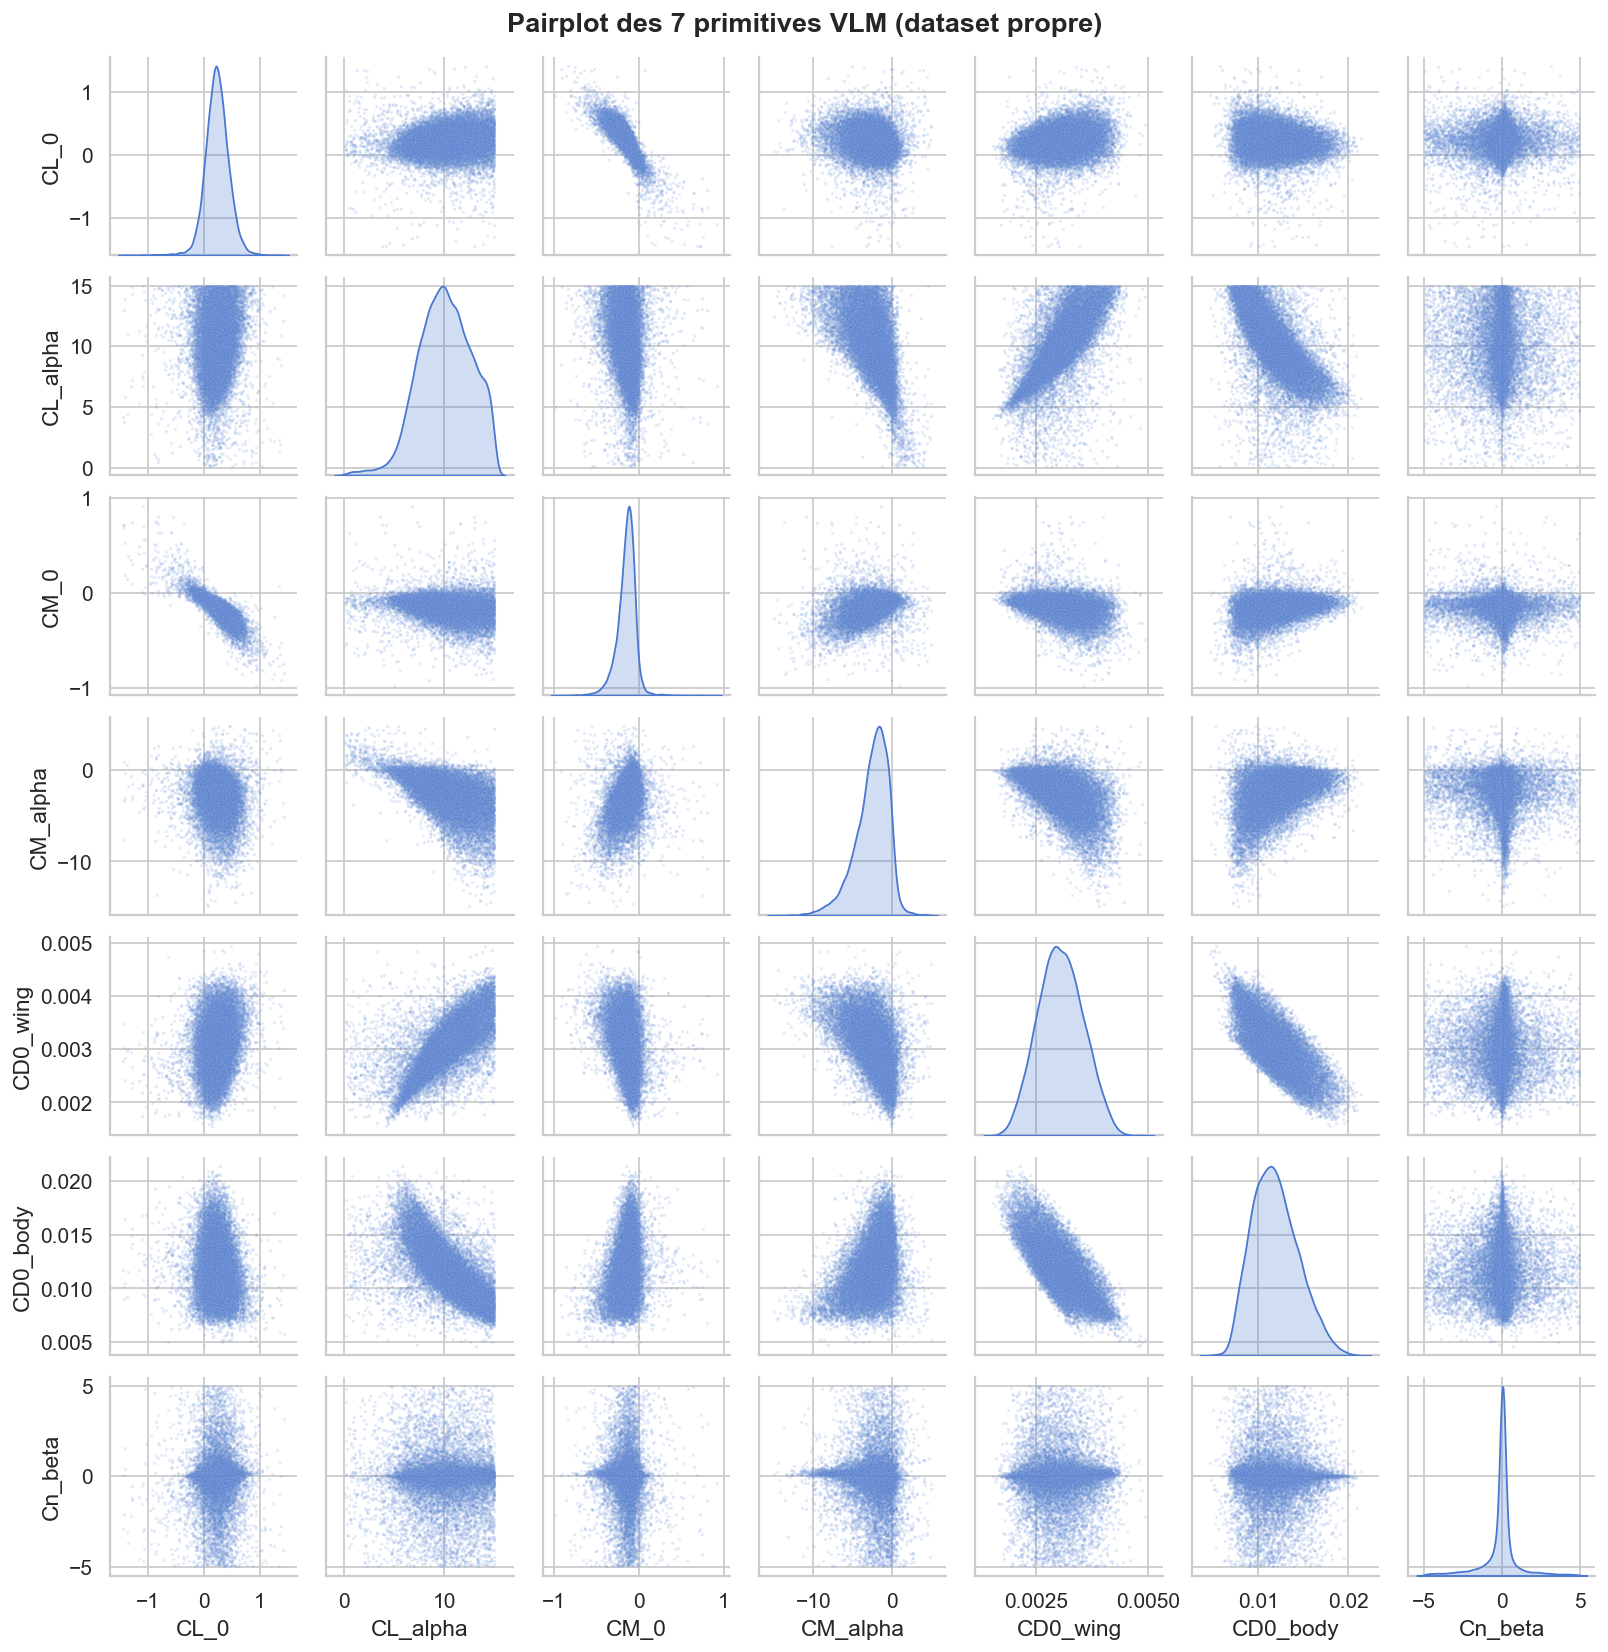

In [21]:
# ── Scatter matrix des primitives (pairplot) ──
g = sns.pairplot(df_Y_clean, diag_kind="kde", plot_kws={"s": 3, "alpha": 0.15},
                 diag_kws={"fill": True}, height=1.8)
g.figure.suptitle("Pairplot des 7 primitives VLM (dataset propre)", fontweight="bold", y=1.01)
plt.show()

## 9. Résumé & recommandations

In [22]:
# ── Résumé automatique de la qualité des données ──
print("=" * 70)
print("         RÉSUMÉ — QUALITÉ DU DATASET POUR LE SURROGATE")
print("=" * 70)

print(f"\n1. TAILLE")
print(f"   Brut : {len(X_raw)} samples")
print(f"   Propre (toutes primitives in bounds) : {n_clean} ({100*n_clean/len(X_raw):.1f}%)")
print(f"   Rejetés (divergence VLM) : {n_rejected} ({100*n_rejected/len(X_raw):.1f}%)")

print(f"\n2. OUTLIERS VLM PAR PRIMITIVE")
for key in PRIMITIVE_TARGETS:
    lo, hi = _TARGET_CLIP[key]
    n_out = outlier_masks[key].sum()
    pct = 100 * n_out / len(df_Y)
    status = "OK" if pct < 5 else "ATTENTION" if pct < 20 else "CRITIQUE"
    print(f"   {key:<12} {n_out:>5} outliers ({pct:>5.1f}%) [{status}]")

print(f"\n3. FEATURES")
print(f"   Variables de design : {N_VARS}")
print(f"   Features augmentées : {X_aug.shape[1]}")
print(f"   NaN : {n_nan} | Inf : {n_inf}")
n_colinear = len(high_corr_pairs)
print(f"   Paires colinéaires (|r|>0.95) : {n_colinear}")

print(f"\n4. COUVERTURE DU DESIGN SPACE")
poor_coverage = [(VAR_NAMES[j], coverage_pcts[j]) for j in range(N_VARS) if coverage_pcts[j] < 0.80]
if poor_coverage:
    for var, cov in poor_coverage:
        print(f"   ⚠ {var}: {100*cov:.1f}% (sous-couverture)")
else:
    print(f"   Toutes les variables couvrent > 80% de leur plage")
print(f"   Couverture moyenne : {100*np.mean(coverage_pcts):.1f}%")

print(f"\n5. RECOMMANDATIONS POUR LE TRAINING")
print(f"   → Entraîner sur les {n_clean} samples propres (pas sur les 10k bruts)")
print(f"   → Évaluer le R² uniquement sur les samples propres")
if n_colinear > 3:
    print(f"   → {n_colinear} paires colinéaires : considérer PCA ou feature selection")
sk_targets = [(key, abs(skew(Y_scaled[:, j]))) for j, key in enumerate(PRIMITIVE_TARGETS)]
sk_high = [(k, s) for k, s in sk_targets if s > 1.5]
if sk_high:
    names = ", ".join(k for k, _ in sk_high)
    print(f"   → Targets asymétriques ({names}) : considérer log-transform ou robust scaler")

print("\n" + "=" * 70)

         RÉSUMÉ — QUALITÉ DU DATASET POUR LE SURROGATE

1. TAILLE
   Brut : 60000 samples
   Propre (toutes primitives in bounds) : 20930 (34.9%)
   Rejetés (divergence VLM) : 39070 (65.1%)

2. OUTLIERS VLM PAR PRIMITIVE
   CL_0         20943 outliers ( 34.9%) [CRITIQUE]
   CL_alpha     33303 outliers ( 55.5%) [CRITIQUE]
   CM_0         19400 outliers ( 32.3%) [CRITIQUE]
   CM_alpha     22101 outliers ( 36.8%) [CRITIQUE]
   CD0_wing         0 outliers (  0.0%) [OK]
   CD0_body         0 outliers (  0.0%) [OK]
   Cn_beta      31013 outliers ( 51.7%) [CRITIQUE]

3. FEATURES
   Variables de design : 30
   Features augmentées : 52
   NaN : 0 | Inf : 0
   Paires colinéaires (|r|>0.95) : 6

4. COUVERTURE DU DESIGN SPACE
   Toutes les variables couvrent > 80% de leur plage
   Couverture moyenne : 100.0%

5. RECOMMANDATIONS POUR LE TRAINING
   → Entraîner sur les 20930 samples propres (pas sur les 10k bruts)
   → Évaluer le R² uniquement sur les samples propres
   → 6 paires colinéaires : cons